============================================================
Cervical Cancer Early Prediction — Dual Experiment Pipeline
Experiment A: Demographic + Behavioral Features Only
Experiment B: + Basic Clinical Screening (Hinselmann, Schiller, Citology)
Core: Hybrid Soft-Voting Ensemble Models
============================================================

## 0. Imports and setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = os.path.dirname(os.path.abspath("kag_risk_factors_cervical_cancer.csv"))
if not os.path.isdir(BASE_DIR):
    BASE_DIR = os.getcwd()
print(f"Using output directory: {BASE_DIR}")

# os.chdir(os.path.dirname(os.path.abspath(__file__)))

# Core ML
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve
)

# Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# SHAP (optional)
try:
    import shap
    SHAP_AVAILABLE = True
except ModuleNotFoundError:
    print("Warning: shap not found. Skipping SHAP analysis.")
    SHAP_AVAILABLE = False

Using output directory: d:\vscode\Code\FYP


## 1. Feature group definitions and experiment configuration

In [2]:
# ============================================================
# FEATURE GROUP DEFINITIONS
# ============================================================
# Experiment A: Pure early-stage features (no clinical tests needed)
#   — Only demographic info + self-reported behavioral risk factors
#   — Simulates a questionnaire-only screening scenario
#
# Experiment B: A + basic non-invasive screening results
#   — Adds Hinselmann (colposcopy), Schiller (iodine stain), Citology (Pap smear)
#   — These 3 are separate screening methods, NOT the biopsy (target)
#   — Simulates: "patient has had basic screening, predict biopsy need"
# ============================================================

EXP_A_FEATURES = [
    'Age',
    'Number of sexual partners',
    'First sexual intercourse',
    'Num of pregnancies',
    'Smokes',
    'Smokes (years)',
    'Smokes (packs/year)',
    'Hormonal Contraceptives',
    'Hormonal Contraceptives (years)',
    'IUD',
    'IUD (years)',
    'STDs',
    'STDs (number)',
    'STDs:condylomatosis',
    'STDs:vaginal condylomatosis',
    'STDs:vulvo-perineal condylomatosis',
    'STDs:syphilis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes',
    'STDs:molluscum contagiosum',
    'STDs:HIV',
    'STDs:Hepatitis B',
    'STDs:HPV',
    'STDs: Number of diagnosis',
    'Dx:Cancer',
    'Dx:CIN',
    'Dx:HPV',
    'Dx',
]

EXP_B_EXTRA = ['Hinselmann', 'Schiller', 'Citology']
EXP_B_FEATURES = EXP_A_FEATURES + EXP_B_EXTRA
# IMPORTANT NOTE:
# ExpB is NOT early prediction.
# It represents a post-screening diagnostic support scenario.

TARGET = "Biopsy"

EXPERIMENT_CONFIGS = {
    "ExpA_EarlyOnly":      EXP_A_FEATURES,
    "ExpB_WithScreening":  EXP_B_FEATURES,
}

## 2. Helper functions

In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def evaluate_model(model, X_test, y_test, threshold=0.3):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "AUC":       round(roc_auc_score(y_test, y_prob), 4),
        "PR-AUC":    round(average_precision_score(y_test, y_prob), 4),
    }
    return metrics, y_pred, y_prob


def replace_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)


def print_section(title):
    print("\n" + "=" * 65)
    print(f"  {title}")
    print("=" * 65)


def get_pos_weight(y_train):
    return (y_train == 0).sum() / max((y_train == 1).sum(), 1)


def safe_save_csv(df, filename):
    path = os.path.join(BASE_DIR, filename)
    try:
        df.to_csv(path)
    except PermissionError:
        fallback = os.path.join(os.path.expanduser("~"), filename)
        print(f"  [WARN] Permission denied saving {path}. Falling back to {fallback}")
        df.to_csv(fallback)
        path = fallback
    return path

## 3. Load and preprocess data

In [4]:
# ============================================================
# 1. LOAD & PREPROCESS DATA
# ============================================================
print_section("LOADING & PREPROCESSING DATA")

df_raw = pd.read_csv("kag_risk_factors_cervical_cancer.csv")
df_raw = df_raw.replace("?", np.nan)

# Drop high-missing / zero-variance columns
drop_cols = [
    'STDs: Time since first diagnosis',
    'STDs: Time since last diagnosis',
    'STDs:cervical condylomatosis',
    'STDs:AIDS',
]
df_raw = df_raw.drop(
    columns=[c for c in drop_cols if c in df_raw.columns], errors='ignore'
)

# Convert all to numeric
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

# Fill missing with median (robust to outliers)
df_raw = df_raw.fillna(df_raw.median())

# IQR Winsorization on continuous columns
continuous_cols = [
    'Age', 'Number of sexual partners', 'First sexual intercourse',
    'Smokes (packs/year)', 'Num of pregnancies', 'IUD (years)',
]
for col in continuous_cols:
    if col in df_raw.columns:
        df_raw[col] = replace_outliers_iqr(df_raw[col])

print(f"Dataset shape after cleaning: {df_raw.shape}")
print(f"Target ({TARGET}) distribution: {df_raw[TARGET].value_counts().to_dict()}")


  LOADING & PREPROCESSING DATA
Dataset shape after cleaning: (858, 32)
Target (Biopsy) distribution: {0: 803, 1: 55}


## 4. Result stores initialization

In [5]:
# ============================================================
# MASTER RESULTS STORE
# ============================================================
# Stores results for every experiment × phase for final comparison
all_results   = {}   # {exp_name: {phase: DataFrame}}
all_roc_data  = {}   # {exp_name: {phase: {model_name: (fpr, tpr, auc)}}}
all_best_models = {} # {exp_name: best_fitted_model}
all_tuned_models = {} # {exp_name: tuned_model_dict}
all_X_test    = {}
all_y_test    = {}
all_scalers   = {}
all_selected  = {}   # {exp_name: selected_features}

## 5. Main experiment loop (Phase 1-4)

In [6]:
# ============================================================
# MAIN EXPERIMENT LOOP
# ============================================================
for exp_name, feature_list in EXPERIMENT_CONFIGS.items():

    print_section(f"EXPERIMENT: {exp_name}")

    # Filter to only columns that exist in the dataset
    valid_features = [f for f in feature_list if f in df_raw.columns]
    missing = set(feature_list) - set(valid_features)
    if missing:
        print(f"  [WARN] Missing columns (skipped): {missing}")

    X_full = df_raw[valid_features]
    y_full = df_raw[TARGET]

    print(f"  Features available: {len(valid_features)}")
    print(f"  Positive rate: {y_full.mean():.3f}")
    if exp_name == "ExpB_WithScreening":
        print("  NOTE: This setting includes clinical screening results (potential leakage-level features)")

    all_results[exp_name]  = {}
    all_roc_data[exp_name] = {}

    # ----------------------------------------------------------
    # PHASE 1: Single Model Baseline (SMOTE, no tuning)
    # ----------------------------------------------------------
    print(f"\n  --- [{exp_name}] PHASE 1: Single Model Baseline ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    smote = SMOTE(random_state=42)
    X_tr_bal, y_tr_bal = smote.fit_resample(X_train_s, y_train)

    pw = get_pos_weight(y_train)
    base_models = {
        "SVC":          SVC(probability=True, class_weight='balanced', random_state=42),
        "KNN":          KNeighborsClassifier(),
        "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
        "XGBoost":      XGBClassifier(
                            scale_pos_weight=pw, eval_metric='logloss', random_state=42
                        ),
    }

    p1_res, p1_roc = {}, {}
    for name, model in base_models.items():
        model.fit(X_tr_bal, y_tr_bal)
        metrics, _, y_prob = evaluate_model(model, X_test_s, y_test)
        p1_res[name] = metrics
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        p1_roc[name] = (fpr, tpr, metrics["AUC"])
        print(f"    {name}: Acc={metrics['Accuracy']} Rec={metrics['Recall']} "
              f"F1={metrics['F1']} AUC={metrics['AUC']} PR-AUC={metrics['PR-AUC']}")

    all_results[exp_name]["Phase1_Baseline"] = pd.DataFrame(p1_res).T
    all_roc_data[exp_name]["Phase1_Baseline"] = p1_roc

    # ----------------------------------------------------------
    # PHASE 2: Feature Selection (RFE + Tree Importance)
    # ----------------------------------------------------------
    print(f"\n  --- [{exp_name}] PHASE 2: Feature Selection ---")

    n_select = min(18, len(valid_features))

    rf_rfe = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rfe    = RFE(estimator=rf_rfe, n_features_to_select=n_select, step=1)
    rfe.fit(X_train_s, y_train)
    rfe_selected = X_full.columns[rfe.support_].tolist()

    rf_imp = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    rf_imp.fit(X_train_s, y_train)
    importances  = pd.Series(rf_imp.feature_importances_, index=X_full.columns).sort_values(ascending=False)
    tree_top     = importances.head(n_select).index.tolist()

    overlap   = [f for f in rfe_selected if f in tree_top]
    fill      = [f for f in tree_top if f not in overlap]
    selected  = (overlap + fill)[:n_select]
    all_selected[exp_name] = selected

    print(f"    Selected {len(selected)} features: {selected}")

    # Save feature importance plot per experiment
    plt.figure(figsize=(10, 6))
    importances[selected].sort_values().plot(kind='barh', color='steelblue')
    plt.title(f"Feature Importance — {exp_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig(f"feature_importance_{exp_name}.png", dpi=150)
    plt.close()
    print(f"    Saved: feature_importance_{exp_name}.png")

    # ----------------------------------------------------------
    # PHASE 3: Hybrid Soft-Voting Models (selected features)
    # IMPORTANT: Feature selection is performed ONLY on training data
    # ----------------------------------------------------------
    print(f"\n  --- [{exp_name}] PHASE 3: Hybrid Models (Untuned) ---")

    X_sel = df_raw[selected]
    X_train3, X_test3, y_train3, y_test3 = train_test_split(
        X_sel, y_full, test_size=0.2, random_state=42, stratify=y_full
    )
    scaler3   = StandardScaler()
    X_tr3_s   = scaler3.fit_transform(X_train3)
    X_te3_s   = scaler3.transform(X_test3)

    # Do not apply SMOTEENN in Phase 3 to preserve the hybrid model evaluation behavior
    X_tr3_bal, y_tr3_bal = X_tr3_s, y_train3

    pw3 = get_pos_weight(y_train3)

    def make_svc():
        return SVC(probability=True, class_weight='balanced', random_state=42)
    def make_knn():
        return KNeighborsClassifier()
    def make_rf():
        return RandomForestClassifier(class_weight='balanced', random_state=42)
    def make_xgb():
        return XGBClassifier(scale_pos_weight=pw3, eval_metric='logloss', random_state=42)

    phase3_models = {
        # Individual baselines (for reference)
        "SVC":             make_svc(),
        "KNN":             make_knn(),
        "RandomForest":    make_rf(),
        "XGBoost":         make_xgb(),
        # Core hybrid models
        "Hybrid_SVC+KNN":  VotingClassifier(
                               estimators=[('svc', make_svc()), ('knn', make_knn())],
                               voting='soft'
                           ),
        "Hybrid_RF+SVC":   VotingClassifier(
                               estimators=[('rf', make_rf()), ('svc', make_svc())],
                               voting='soft'
                           ),
        "Hybrid_XGB+KNN":  VotingClassifier(
                               estimators=[('xgb', make_xgb()), ('knn', make_knn())],
                               voting='soft'
                           ),
        "Hybrid_RF+XGB":   VotingClassifier(
                               estimators=[('rf', make_rf()), ('xgb', make_xgb())],
                               voting='soft'
                           ),
        "Hybrid_ALL4":     VotingClassifier(
                               estimators=[
                                   ('svc', make_svc()), ('knn', make_knn()),
                                   ('rf',  make_rf()),  ('xgb', make_xgb()),
                               ],
                               voting='soft'
                           ),
        "Stacking_ALL4":  StackingClassifier(
                               estimators=[
                                   ('svc', make_svc()),
                                   ('knn', make_knn()),
                                   ('rf',  make_rf()),
                                   ('xgb', make_xgb()),
                               ],
                               final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                               passthrough=False,
                               cv=5,
                               n_jobs=-1
                           ),
    }

    p3_res, p3_roc = {}, {}
    for name, model in phase3_models.items():
        t0 = time.time()
        model.fit(X_tr3_bal, y_tr3_bal)
        train_time = round(time.time() - t0, 2)
        metrics, _, y_prob = evaluate_model(model, X_te3_s, y_test3)
        metrics["Train_Time(s)"] = train_time
        p3_res[name] = metrics
        fpr, tpr, _ = roc_curve(y_test3, y_prob)
        p3_roc[name] = (fpr, tpr, metrics["AUC"])
        print(f"    {name}: Acc={metrics['Accuracy']} Rec={metrics['Recall']} "
              f"F1={metrics['F1']} AUC={metrics['AUC']} PR-AUC={metrics['PR-AUC']}")

    all_results[exp_name]["Phase3_Hybrid"]  = pd.DataFrame(p3_res).T
    all_roc_data[exp_name]["Phase3_Hybrid"] = p3_roc

    # ----------------------------------------------------------
    # PHASE 4: Hyperparameter Tuning → Optimized Hybrid Models
    # ----------------------------------------------------------
    print(f"\n  --- [{exp_name}] PHASE 4: Tuned Hybrid Models ---")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Grid Search: SVC
    svc_gs = GridSearchCV(
        SVC(probability=True, class_weight='balanced', random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']},
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    svc_gs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    SVC best: {svc_gs.best_params_}  CV-AUC={round(svc_gs.best_score_, 4)}")

    # Random Search: KNN
    knn_rs = RandomizedSearchCV(
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'],
         'metric': ['euclidean', 'manhattan']},
        n_iter=12, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
    )
    knn_rs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    KNN best: {knn_rs.best_params_}  CV-AUC={round(knn_rs.best_score_, 4)}")

    # Grid Search: Random Forest
    rf_gs = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5]},
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    rf_gs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    RF  best: {rf_gs.best_params_}  CV-AUC={round(rf_gs.best_score_, 4)}")

    # Random Search: XGBoost
    xgb_rs = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=pw3, eval_metric='logloss', random_state=42),
        {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7],
         'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.8, 1.0]},
        n_iter=15, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
    )
    xgb_rs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    XGB best: {xgb_rs.best_params_}  CV-AUC={round(xgb_rs.best_score_, 4)}")

    # Build tuned hybrid models (weighted soft-voting)
    tuned_models = {
        # Tuned individuals (for ablation reference)
        "Tuned_SVC":     svc_gs.best_estimator_,
        "Tuned_KNN":     knn_rs.best_estimator_,
        "Tuned_RF":      rf_gs.best_estimator_,
        "Tuned_XGB":     xgb_rs.best_estimator_,
        # Core tuned hybrids — weighted by individual CV-AUC scores
        "Tuned_Hybrid_SVC+KNN": VotingClassifier(
            estimators=[('svc', svc_gs.best_estimator_),
                        ('knn', knn_rs.best_estimator_)],
            voting='soft', weights=[2, 1]
        ),
        "Tuned_Hybrid_RF+SVC":  VotingClassifier(
            estimators=[('rf',  rf_gs.best_estimator_),
                        ('svc', svc_gs.best_estimator_)],
            voting='soft', weights=[2, 1]
        ),
        "Tuned_Hybrid_XGB+KNN": VotingClassifier(
            estimators=[('xgb', xgb_rs.best_estimator_),
                        ('knn', knn_rs.best_estimator_)],
            voting='soft', weights=[3, 1]
        ),
        "Tuned_Hybrid_RF+XGB":  VotingClassifier(
            estimators=[('rf',  rf_gs.best_estimator_),
                        ('xgb', xgb_rs.best_estimator_)],
            voting='soft', weights=[2, 3]
        ),
        "Tuned_Hybrid_ALL4":    VotingClassifier(
            estimators=[
                ('svc', svc_gs.best_estimator_),
                ('knn', knn_rs.best_estimator_),
                ('rf',  rf_gs.best_estimator_),
                ('xgb', xgb_rs.best_estimator_),
            ],
            voting='soft',
            weights=[
                round(svc_gs.best_score_, 3),
                round(knn_rs.best_score_, 3),
                round(rf_gs.best_score_,  3),
                round(xgb_rs.best_score_, 3),
            ]
        ),
        "Tuned_Stacking_ALL4":  StackingClassifier(
            estimators=[
                ('svc', svc_gs.best_estimator_),
                ('knn', knn_rs.best_estimator_),
                ('rf',  rf_gs.best_estimator_),
                ('xgb', xgb_rs.best_estimator_),
            ],
            final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            passthrough=False,
            cv=5,
            n_jobs=-1
        ),
    }

    p4_res, p4_roc = {}, {}
    for name, model in tuned_models.items():
        t0 = time.time()
        model.fit(X_tr3_bal, y_tr3_bal)
        train_time = round(time.time() - t0, 2)
        metrics, _, y_prob = evaluate_model(model, X_te3_s, y_test3)
        metrics["Train_Time(s)"] = train_time
        p4_res[name] = metrics
        fpr, tpr, _ = roc_curve(y_test3, y_prob)
        p4_roc[name] = (fpr, tpr, metrics["AUC"])
        print(f"    {name}: Acc={metrics['Accuracy']} Rec={metrics['Recall']} "
              f"F1={metrics['F1']} AUC={metrics['AUC']} PR-AUC={metrics['PR-AUC']}")

    all_results[exp_name]["Phase4_Tuned"]  = pd.DataFrame(p4_res).T
    all_roc_data[exp_name]["Phase4_Tuned"] = p4_roc

    # Store test set + best model for later visualizations
    best_name  = pd.DataFrame(p4_res).T["AUC"].idxmax()
    all_best_models[exp_name] = (best_name, tuned_models[best_name])
    all_tuned_models[exp_name] = tuned_models
    all_X_test[exp_name]  = X_te3_s
    all_y_test[exp_name]  = y_test3
    all_scalers[exp_name] = scaler3

    print(f"\n  ★ Best model for {exp_name}: {best_name} "
          f"(AUC={p4_res[best_name]['AUC']})")


  EXPERIMENT: ExpA_EarlyOnly
  Features available: 28
  Positive rate: 0.064

  --- [ExpA_EarlyOnly] PHASE 1: Single Model Baseline ---
    SVC: Acc=0.5814 Rec=0.6364 F1=0.1628 AUC=0.6036 PR-AUC=0.0917
    KNN: Acc=0.7267 Rec=0.5455 F1=0.2034 AUC=0.6652 PR-AUC=0.0982
    RandomForest: Acc=0.8023 Rec=0.1818 F1=0.1053 AUC=0.6968 PR-AUC=0.1915
    XGBoost: Acc=0.843 Rec=0.2727 F1=0.1818 AUC=0.6612 PR-AUC=0.1493

  --- [ExpA_EarlyOnly] PHASE 2: Feature Selection ---
    Selected 18 features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'STDs', 'STDs (number)', 'STDs:vulvo-perineal condylomatosis', 'STDs:HIV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']
    Saved: feature_importance_ExpA_EarlyOnly.png

  --- [ExpA_EarlyOnly] PHASE 3: Hybrid Models (Untuned) ---
    SVC: Acc=0.936 Rec=0.0 F1=0.0 AUC=0.6499 PR-AUC=0.1276
    KNN: A

## 6. Visualizations

### Visualizations introduction

In [7]:
# ============================================================
# VISUALIZATIONS
# ============================================================
print_section("GENERATING VISUALIZATIONS")


  GENERATING VISUALIZATIONS


### ── VIZ 1: ExpA vs ExpB Phase-1 Baseline Comparison ─────────

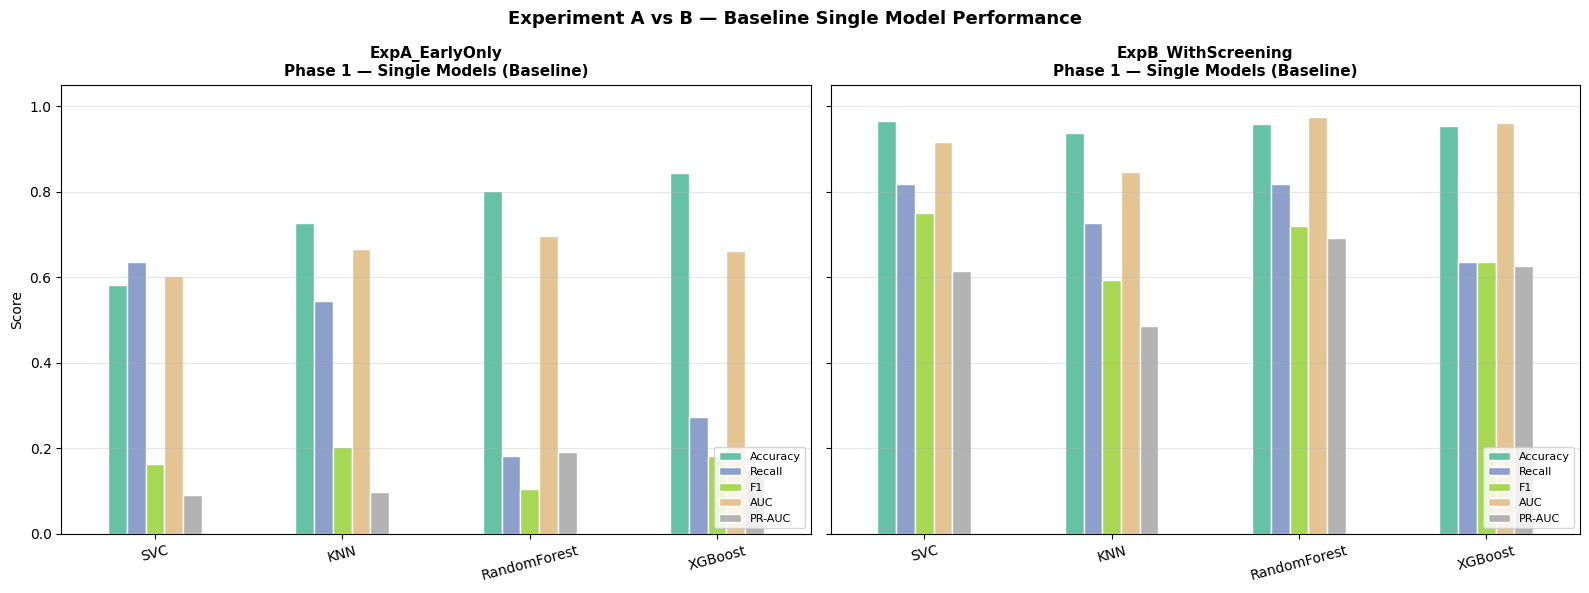

  Saved: viz1_expA_vs_expB_baseline.png


In [8]:
# ── VIZ 1: ExpA vs ExpB Phase-1 Baseline Comparison ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
metrics_show = ["Accuracy", "Recall", "F1", "AUC", "PR-AUC"]
colors = ["#4C9BE8", "#E8734C"]

for ax, (exp_name, color) in zip(axes, zip(EXPERIMENT_CONFIGS.keys(), colors)):
    df_p1 = all_results[exp_name]["Phase1_Baseline"][metrics_show]
    df_p1.plot(kind='bar', ax=ax, ylim=(0, 1.05), colormap='Set2', rot=15, edgecolor='white')
    ax.set_title(f"{exp_name}\nPhase 1 — Single Models (Baseline)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Experiment A vs B — Baseline Single Model Performance",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz1_expA_vs_expB_baseline.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz1_expA_vs_expB_baseline.png")

### ── VIZ 1.5: Recall / Precision vs Threshold — Best Single vs Hybrid ─

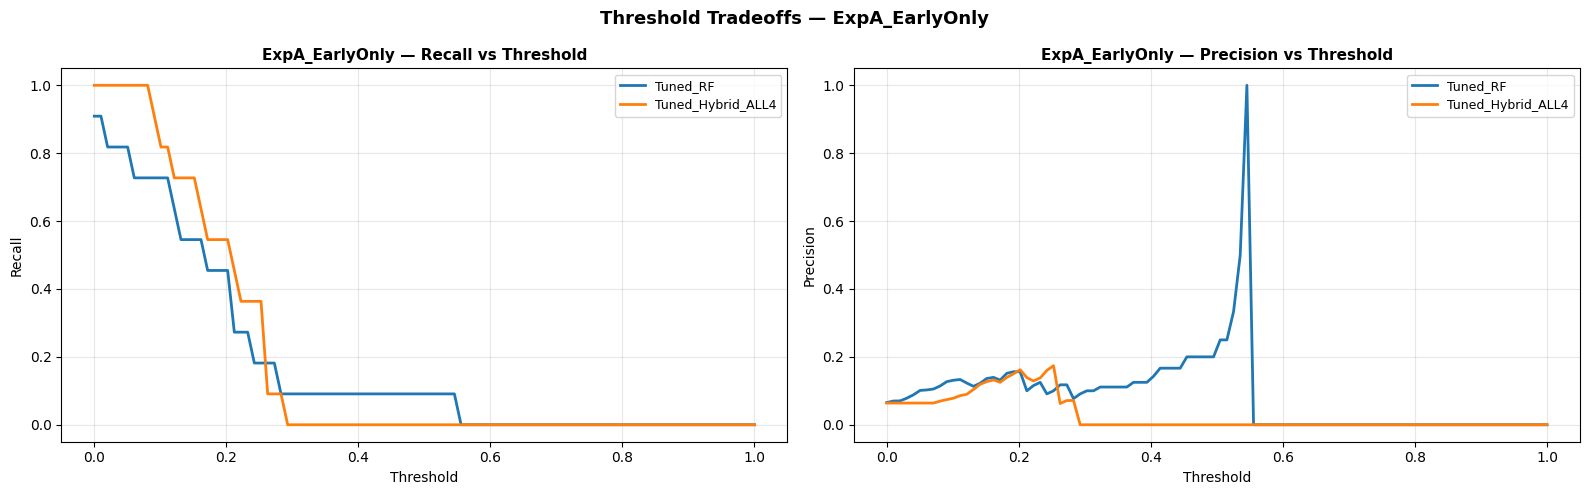

  Saved: viz1a_threshold_curves_ExpA_EarlyOnly.png


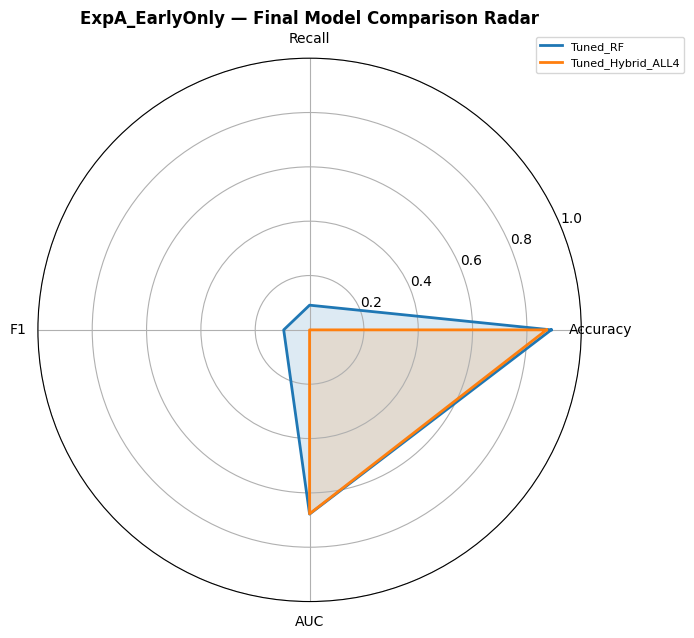

  Saved: viz1b_radar_comparison_ExpA_EarlyOnly.png


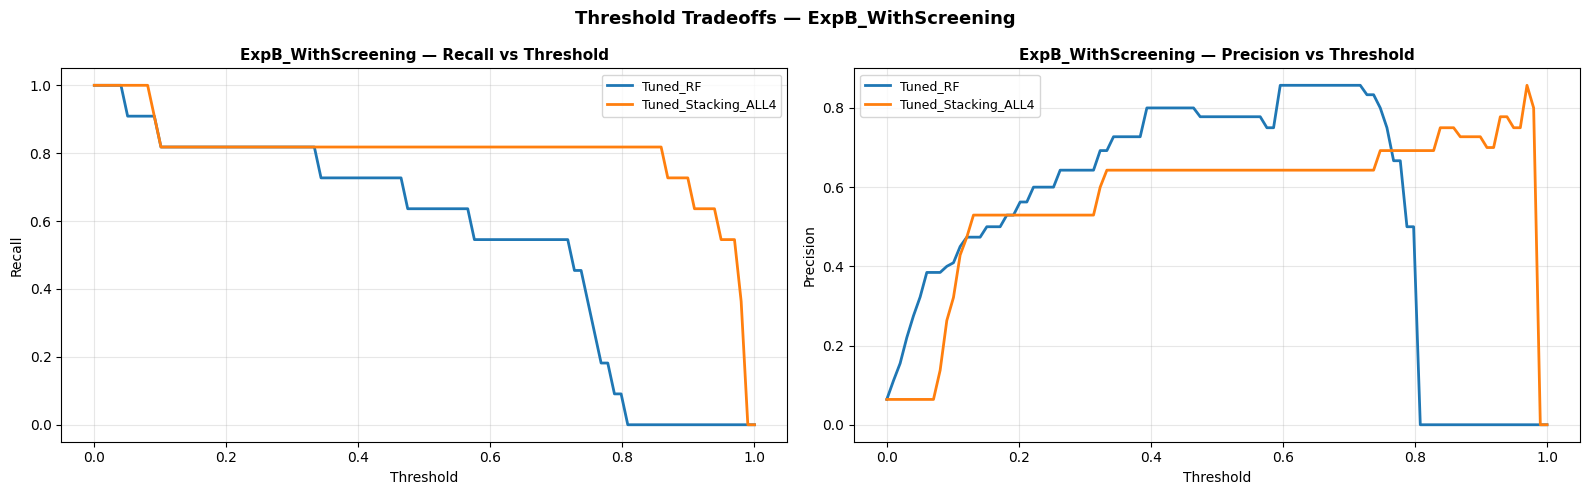

  Saved: viz1a_threshold_curves_ExpB_WithScreening.png


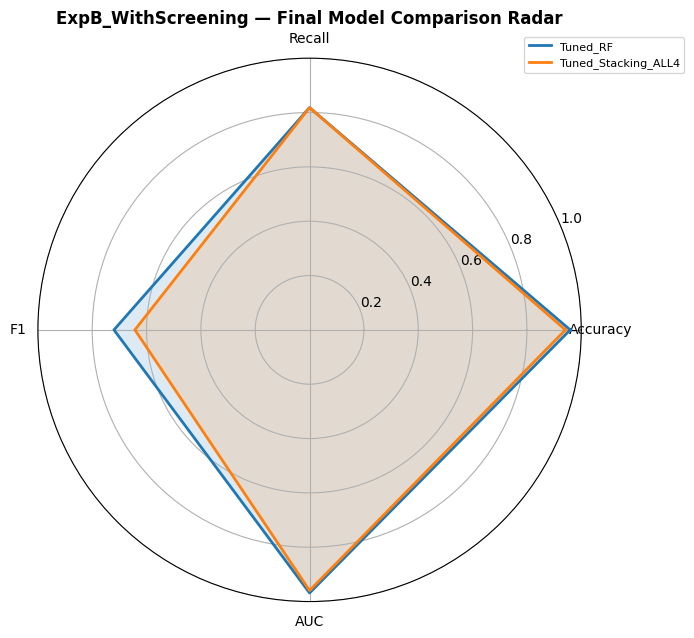

  Saved: viz1b_radar_comparison_ExpB_WithScreening.png


In [9]:
# ── VIZ 1.5: Recall / Precision vs Threshold — Best Single vs Hybrid ─
for exp_name in EXPERIMENT_CONFIGS.keys():
    p4_df = all_results[exp_name]["Phase4_Tuned"]
    single_models = [m for m in ["Tuned_SVC", "Tuned_KNN", "Tuned_RF", "Tuned_XGB"] if m in p4_df.index]
    hybrid_models = [m for m in p4_df.index if m in ["Tuned_Hybrid_ALL4", "Tuned_Stacking_ALL4"]]
    if not single_models or not hybrid_models:
        continue

    best_single = p4_df.loc[single_models, "AUC"].idxmax()
    best_hybrid = p4_df.loc[hybrid_models, "AUC"].idxmax()
    y_true = all_y_test[exp_name]
    y_prob_single = all_tuned_models[exp_name][best_single].predict_proba(all_X_test[exp_name])[:, 1]
    y_prob_hybrid = all_tuned_models[exp_name][best_hybrid].predict_proba(all_X_test[exp_name])[:, 1]

    thresholds = np.linspace(0, 1, 100)
    recall_single, precision_single = [], []
    recall_hybrid, precision_hybrid = [], []

    for t in thresholds:
        pred_single = (y_prob_single > t).astype(int)
        pred_hybrid = (y_prob_hybrid > t).astype(int)
        recall_single.append(recall_score(y_true, pred_single, zero_division=0))
        precision_single.append(precision_score(y_true, pred_single, zero_division=0))
        recall_hybrid.append(recall_score(y_true, pred_hybrid, zero_division=0))
        precision_hybrid.append(precision_score(y_true, pred_hybrid, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(thresholds, recall_single, label=best_single, linewidth=2)
    axes[0].plot(thresholds, recall_hybrid, label=best_hybrid, linewidth=2)
    axes[0].set_title(f"{exp_name} — Recall vs Threshold", fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Recall")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    axes[1].plot(thresholds, precision_single, label=best_single, linewidth=2)
    axes[1].plot(thresholds, precision_hybrid, label=best_hybrid, linewidth=2)
    axes[1].set_title(f"{exp_name} — Precision vs Threshold", fontsize=11, fontweight='bold')
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"Threshold Tradeoffs — {exp_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"viz1a_threshold_curves_{exp_name}.png", dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: viz1a_threshold_curves_{exp_name}.png")

    categories = ["Accuracy", "Recall", "F1", "AUC"]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    values = []
    labels = [best_single, best_hybrid]
    for model_name in labels:
        model_scores = all_results[exp_name]["Phase4_Tuned"].loc[model_name, categories].tolist()
        values.append(model_scores + [model_scores[0]])

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)
    for model_name, vals in zip(labels, values):
        ax.plot(angles, vals, label=model_name, linewidth=2)
        ax.fill(angles, vals, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title(f"{exp_name} — Final Model Comparison Radar", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05), fontsize=8)
    plt.tight_layout()
    plt.savefig(f"viz1b_radar_comparison_{exp_name}.png", dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: viz1b_radar_comparison_{exp_name}.png")

### ── VIZ 2: Phase 3 Hybrid Models — ExpA vs ExpB ─────────────

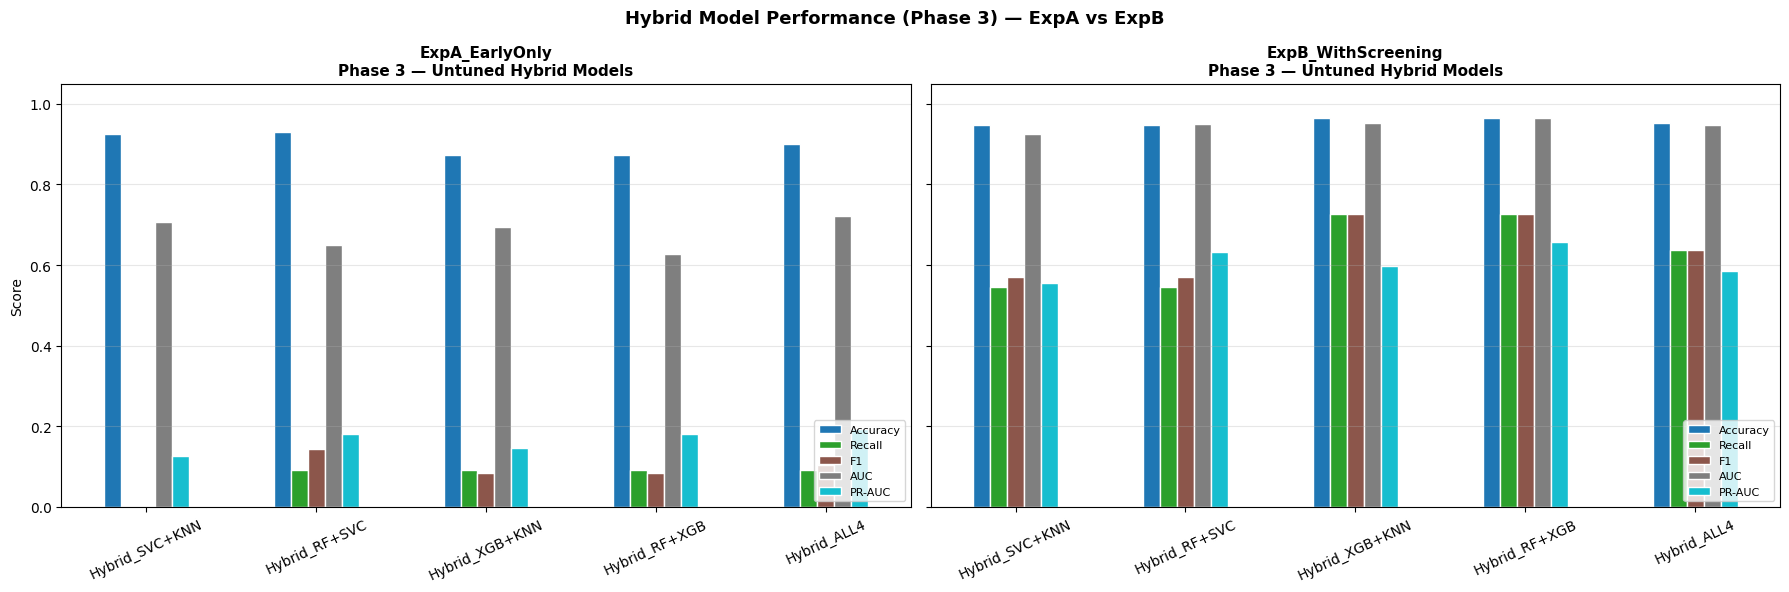

  Saved: viz2_phase3_hybrid_comparison.png


In [10]:
# ── VIZ 2: Phase 3 Hybrid Models — ExpA vs ExpB ─────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
hybrid_only = ["Hybrid_SVC+KNN", "Hybrid_RF+SVC",
               "Hybrid_XGB+KNN", "Hybrid_RF+XGB", "Hybrid_ALL4"]

for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    df_p3 = all_results[exp_name]["Phase3_Hybrid"]
    df_p3_hybrid = df_p3[df_p3.index.isin(hybrid_only)][metrics_show]
    df_p3_hybrid.plot(kind='bar', ax=ax, ylim=(0, 1.05),
                      colormap='tab10', rot=25, edgecolor='white')
    ax.set_title(f"{exp_name}\nPhase 3 — Untuned Hybrid Models", fontsize=11, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Hybrid Model Performance (Phase 3) — ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz2_phase3_hybrid_comparison.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz2_phase3_hybrid_comparison.png")

### ── VIZ 3: Phase 4 Tuned Hybrids — ExpA vs ExpB ─────────────

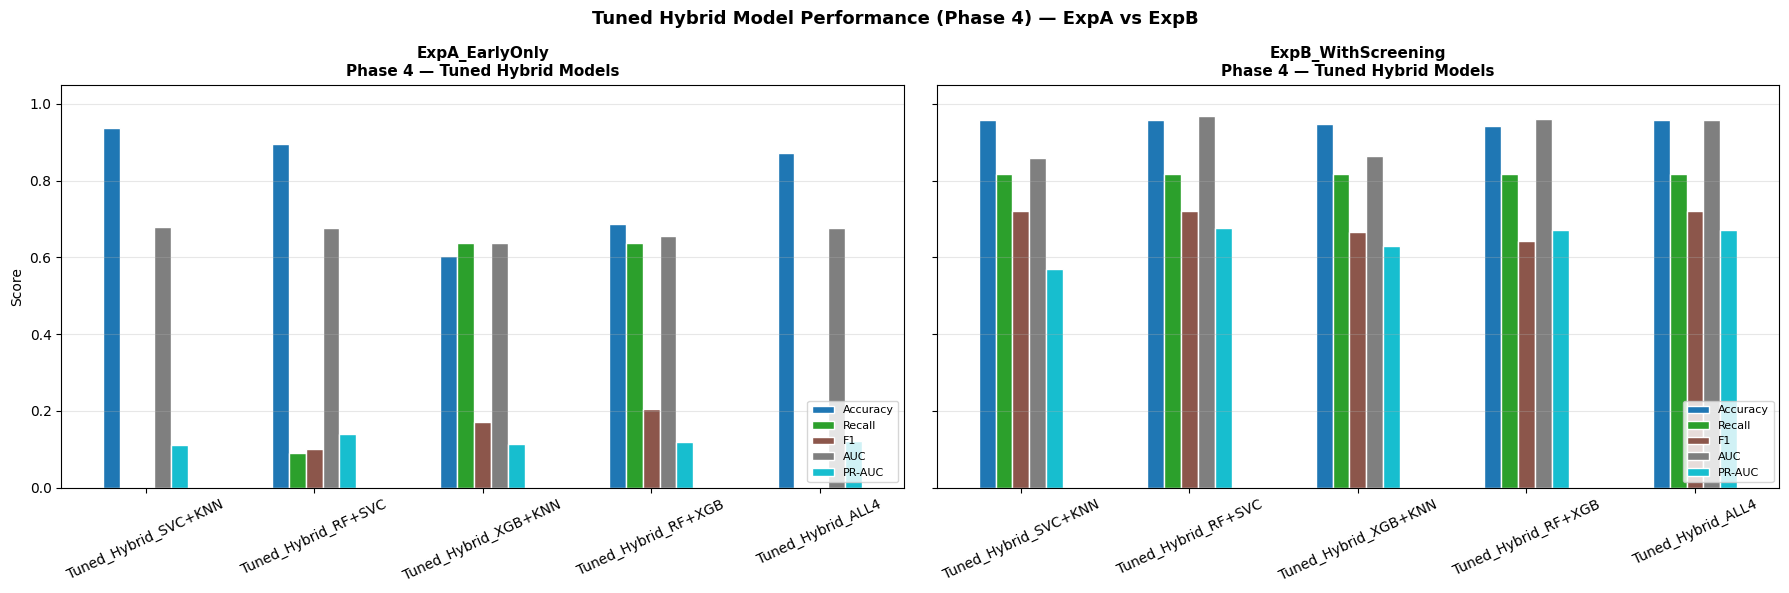

  Saved: viz3_phase4_tuned_hybrid_comparison.png


In [11]:
# ── VIZ 3: Phase 4 Tuned Hybrids — ExpA vs ExpB ─────────────
tuned_hybrid_only = ["Tuned_Hybrid_SVC+KNN", "Tuned_Hybrid_RF+SVC",
                     "Tuned_Hybrid_XGB+KNN", "Tuned_Hybrid_RF+XGB", "Tuned_Hybrid_ALL4"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    df_p4 = all_results[exp_name]["Phase4_Tuned"]
    df_p4_hybrid = df_p4[df_p4.index.isin(tuned_hybrid_only)][metrics_show]
    df_p4_hybrid.plot(kind='bar', ax=ax, ylim=(0, 1.05),
                      colormap='tab10', rot=25, edgecolor='white')
    ax.set_title(f"{exp_name}\nPhase 4 — Tuned Hybrid Models", fontsize=11, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Tuned Hybrid Model Performance (Phase 4) — ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz3_phase4_tuned_hybrid_comparison.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz3_phase4_tuned_hybrid_comparison.png")

### ── VIZ 4: ROC Curves — Phase 4 Tuned Hybrids (side by side) ─

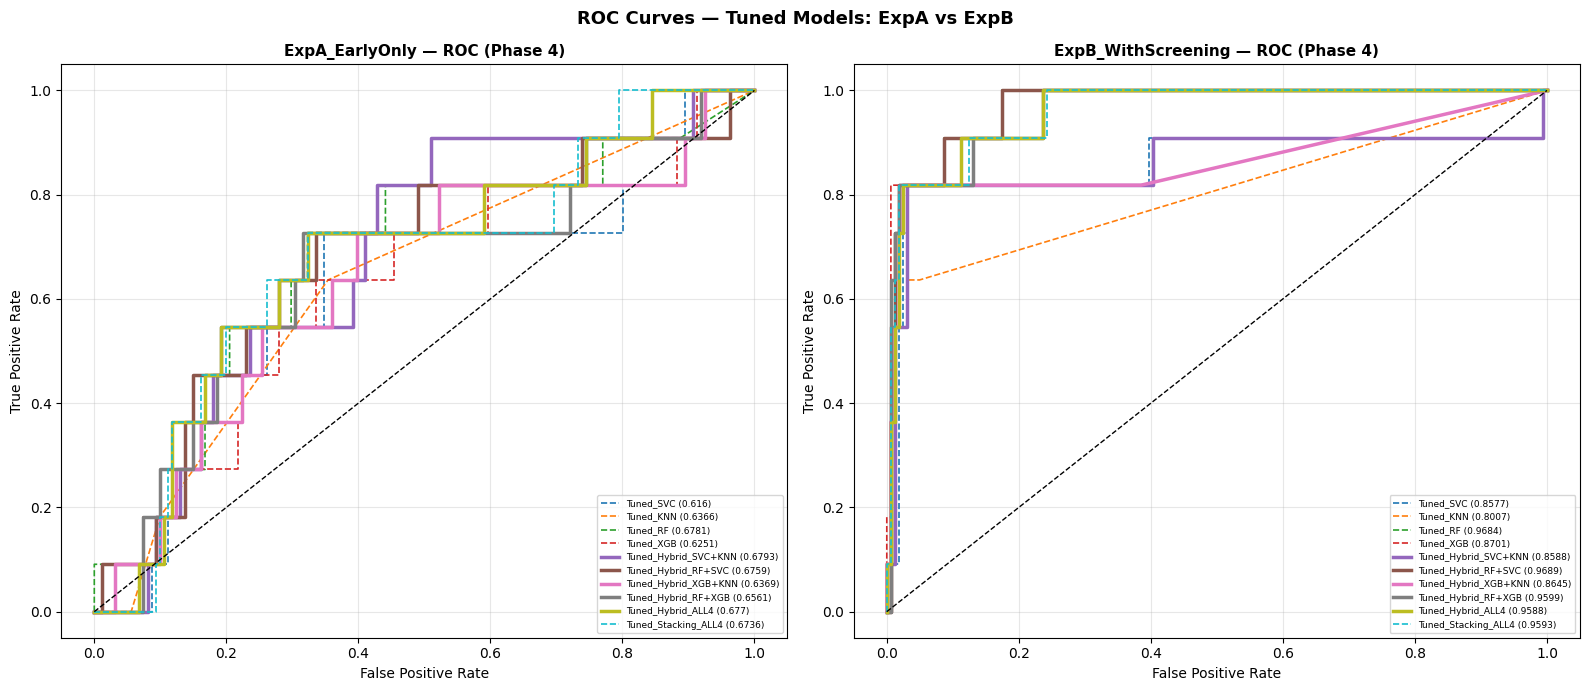

  Saved: viz4_roc_tuned_expA_vs_expB.png


In [12]:
# ── VIZ 4: ROC Curves — Phase 4 Tuned Hybrids (side by side) ─
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    roc_data = all_roc_data[exp_name]["Phase4_Tuned"]
    for name, (fpr, tpr, auc) in roc_data.items():
        lw = 2.5 if "Hybrid" in name else 1.2
        ls = '-'  if "Hybrid" in name else '--'
        ax.plot(fpr, tpr, label=f"{name} ({auc})", linewidth=lw, linestyle=ls)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f"{exp_name} — ROC (Phase 4)", fontsize=11, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=6.5, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves — Tuned Models: ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz4_roc_tuned_expA_vs_expB.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz4_roc_tuned_expA_vs_expB.png")

### ── VIZ 5: AUC Progression — P1 → P3 → P4 per experiment ────

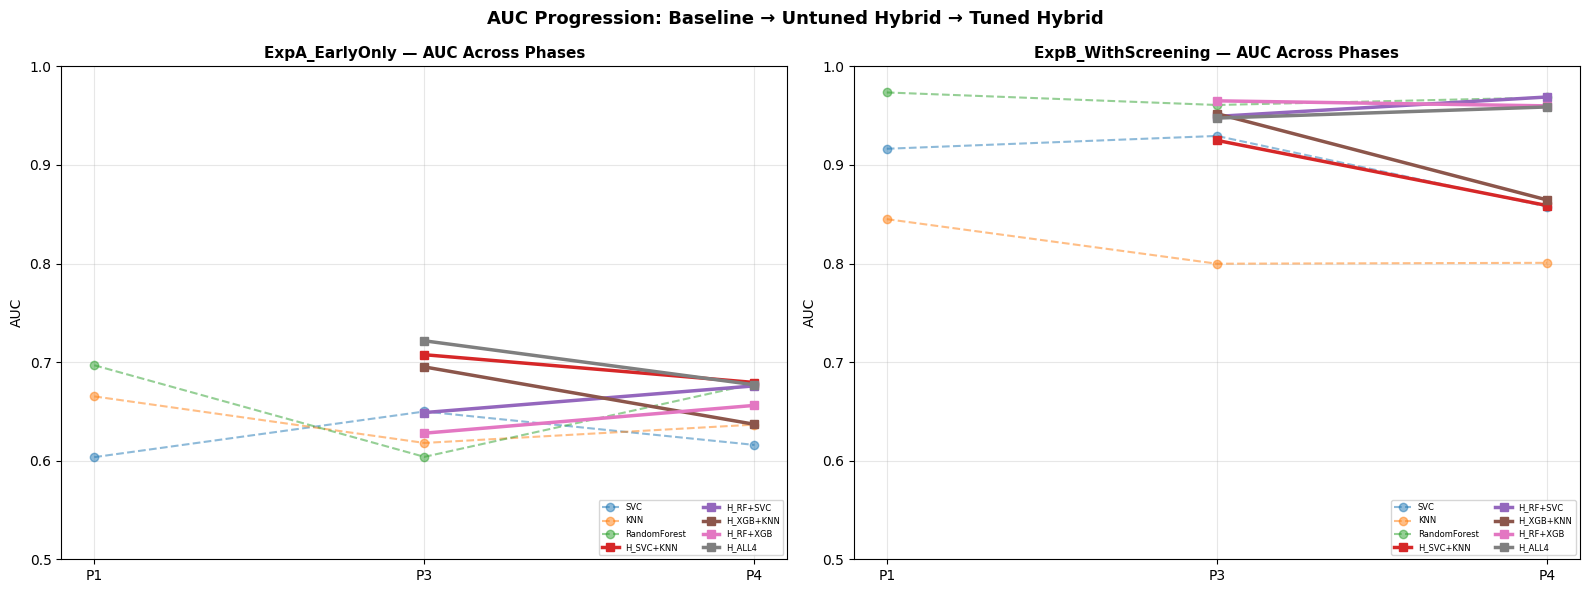

  Saved: viz5_auc_progression.png


In [13]:
# ── VIZ 5: AUC Progression — P1 → P3 → P4 per experiment ────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
phase_map = {
    "Phase1_Baseline": "P1 Baseline",
    "Phase3_Hybrid":   "P3 Hybrid",
    "Phase4_Tuned":    "P4 Tuned",
}
# Track hybrids across phases (matching by suffix)
hybrid_labels_p3 = ["Hybrid_SVC+KNN", "Hybrid_RF+SVC",
                     "Hybrid_XGB+KNN", "Hybrid_RF+XGB", "Hybrid_ALL4"]
hybrid_labels_p4 = ["Tuned_" + h for h in hybrid_labels_p3]

for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    p1_auc = all_results[exp_name]["Phase1_Baseline"]["AUC"]
    p3_df  = all_results[exp_name]["Phase3_Hybrid"]
    p4_df  = all_results[exp_name]["Phase4_Tuned"]

    # Plot individual model trajectories P1 → P4
    for base_model in ["SVC", "KNN", "RandomForest", "XGBoost"]:
        tuned_key = "Tuned_" + ("RF" if base_model == "RandomForest" else base_model)
        if base_model in p3_df.index and tuned_key in p4_df.index:
            y_vals = [
                p1_auc.get(base_model, np.nan),
                p3_df.loc[base_model, "AUC"] if base_model in p3_df.index else np.nan,
                p4_df.loc[tuned_key, "AUC"],
            ]
            ax.plot(["P1", "P3", "P4"], y_vals, marker='o', linestyle='--',
                    alpha=0.5, label=base_model)

    # Plot hybrid trajectories P3 → P4 (bold)
    for h3, h4 in zip(hybrid_labels_p3, hybrid_labels_p4):
        if h3 in p3_df.index and h4 in p4_df.index:
            y_vals = [np.nan, p3_df.loc[h3, "AUC"], p4_df.loc[h4, "AUC"]]
            ax.plot(["P1", "P3", "P4"], y_vals, marker='s', linewidth=2.5,
                    label=h3.replace("Hybrid_", "H_"))

    ax.set_ylim(0.5, 1.0)
    ax.set_title(f"{exp_name} — AUC Across Phases", fontsize=11, fontweight='bold')
    ax.set_ylabel("AUC")
    ax.legend(fontsize=6, loc='lower right', ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle("AUC Progression: Baseline → Untuned Hybrid → Tuned Hybrid",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz5_auc_progression.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz5_auc_progression.png")

### ── VIZ 6: Confusion Matrices — Best Model per Experiment ────

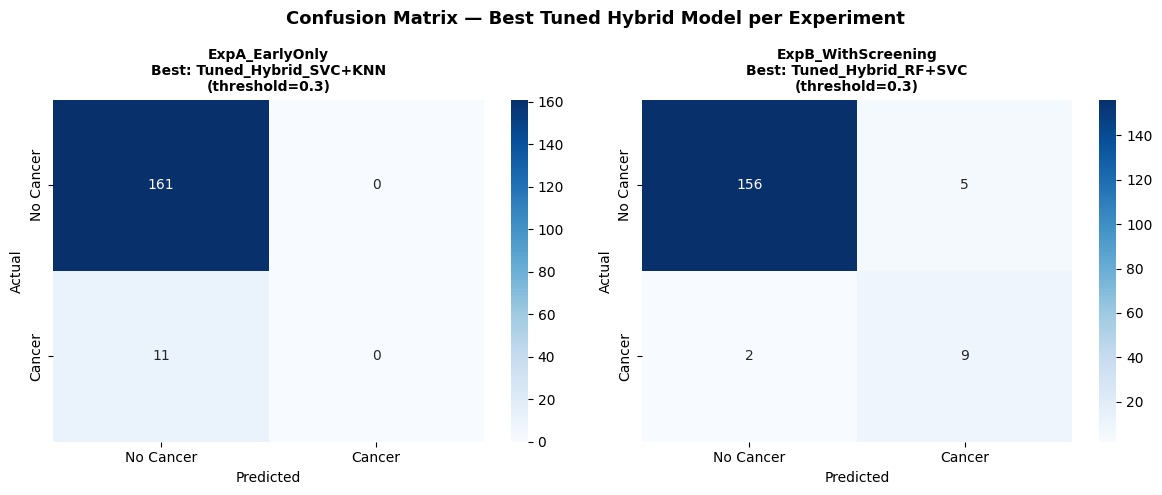

  Saved: viz6_confusion_matrices.png


In [14]:
# ── VIZ 6: Confusion Matrices — Best Model per Experiment ────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    best_name, best_model = all_best_models[exp_name]
    X_te  = all_X_test[exp_name]
    y_te  = all_y_test[exp_name]

    y_prob_best = best_model.predict_proba(X_te)[:, 1]
    # Use 0.3 threshold to boost recall (more important in medical screening)
    y_pred_best = (y_prob_best > 0.3).astype(int)
    cm = confusion_matrix(y_te, y_pred_best)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Cancer', 'Cancer'],
                yticklabels=['No Cancer', 'Cancer'])
    ax.set_title(f"{exp_name}\nBest: {best_name}\n(threshold=0.3)",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix — Best Tuned Hybrid Model per Experiment",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz6_confusion_matrices.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz6_confusion_matrices.png")

### ── VIZ 7: Cross-Experiment Summary Heatmap ─────────────────

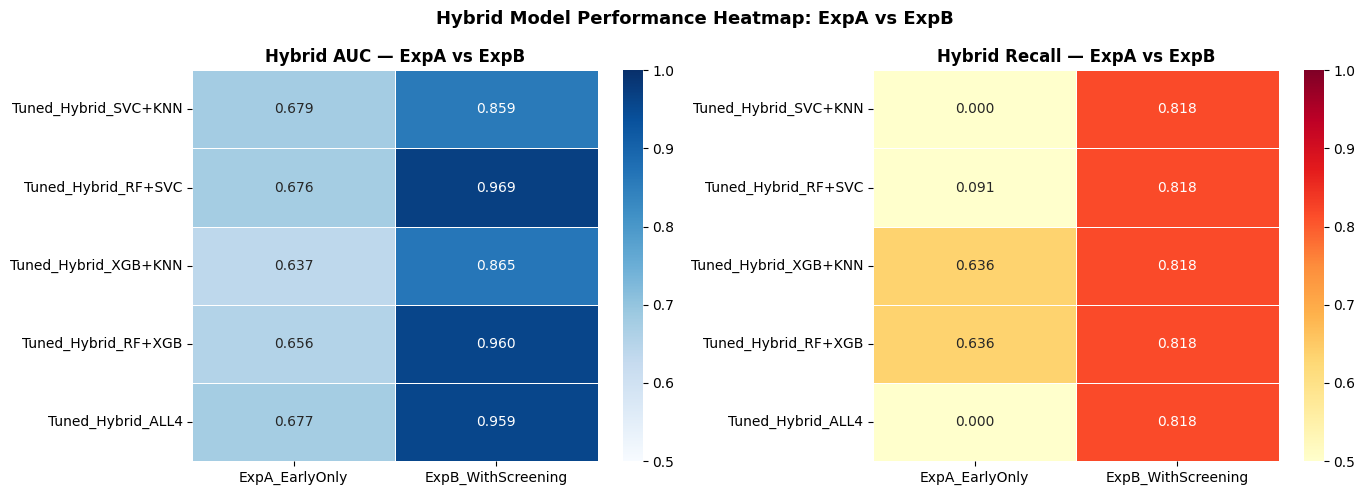

  Saved: viz7_hybrid_heatmap_expA_vs_expB.png


In [15]:
# ── VIZ 7: Cross-Experiment Summary Heatmap ─────────────────
# AUC of all hybrid models across both experiments
rows = {}
for exp_name in EXPERIMENT_CONFIGS.keys():
    p4_df = all_results[exp_name]["Phase4_Tuned"]
    for model_name in tuned_hybrid_only:
        if model_name in p4_df.index:
            rows.setdefault(model_name, {})[exp_name] = p4_df.loc[model_name, "AUC"]

heatmap_df = pd.DataFrame(rows).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(["AUC", "Recall"], axes):
    metric_rows = {}
    for exp_name in EXPERIMENT_CONFIGS.keys():
        p4_df = all_results[exp_name]["Phase4_Tuned"]
        for model_name in tuned_hybrid_only:
            if model_name in p4_df.index:
                metric_rows.setdefault(model_name, {})[exp_name] = p4_df.loc[model_name, metric]
    metric_df = pd.DataFrame(metric_rows).T
    sns.heatmap(metric_df, annot=True, fmt=".3f",
                cmap="Blues" if metric == "AUC" else "YlOrRd",
                ax=ax, vmin=0.5, vmax=1.0, linewidths=0.5)
    ax.set_title(f"Hybrid {metric} — ExpA vs ExpB", fontweight='bold')

plt.suptitle("Hybrid Model Performance Heatmap: ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz7_hybrid_heatmap_expA_vs_expB.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz7_hybrid_heatmap_expA_vs_expB.png")

### ── VIZ 8: Phase 4 Full — Both Experiments All Models ────────

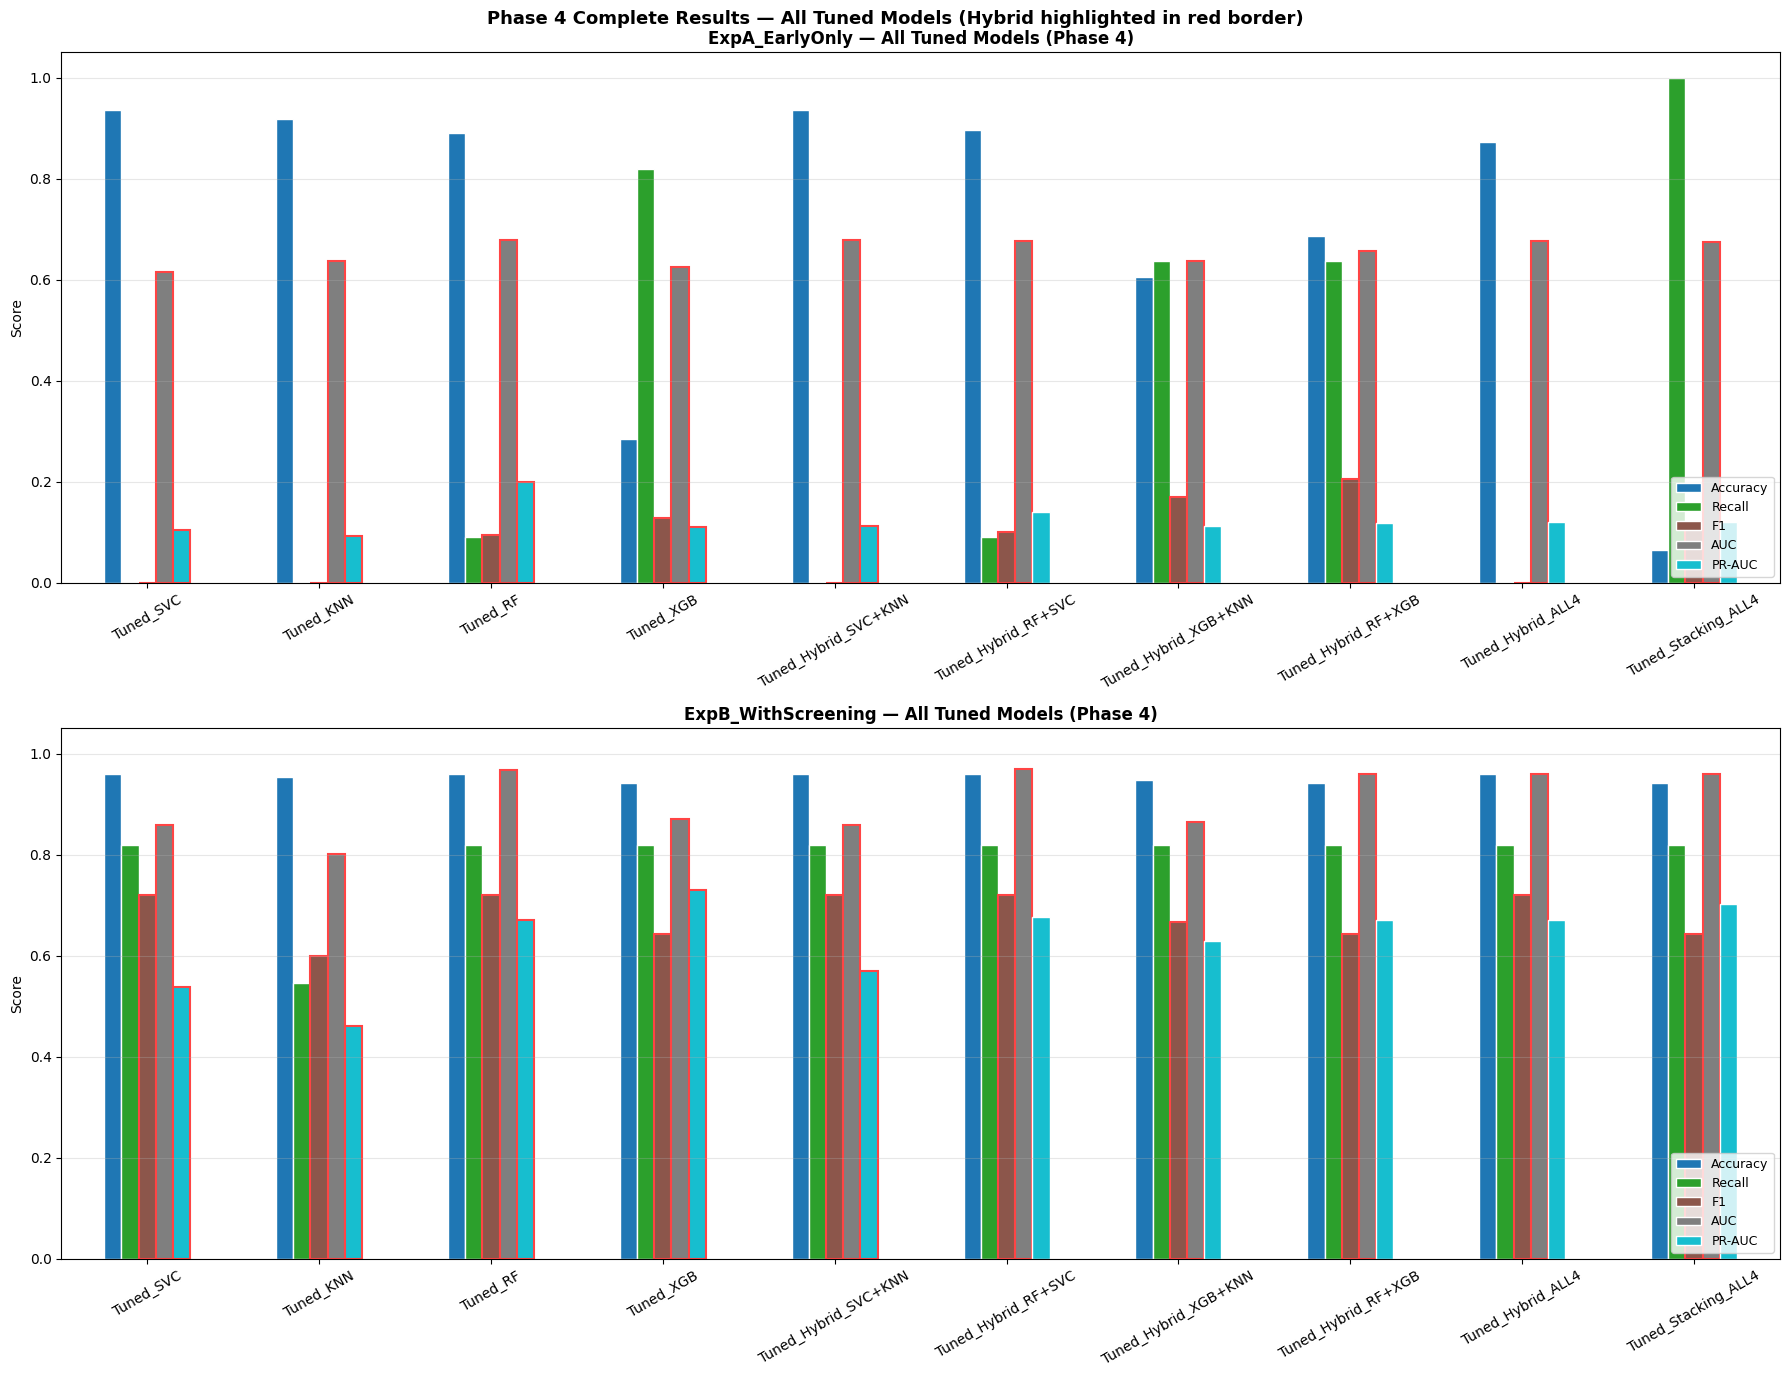

  Saved: viz8_phase4_full_both_experiments.png


In [16]:
# ── VIZ 8: Phase 4 Full — Both Experiments All Models ────────
fig, axes = plt.subplots(2, 1, figsize=(18, 14))
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    df_p4 = all_results[exp_name]["Phase4_Tuned"][metrics_show]
    df_p4.plot(kind='bar', ax=ax, ylim=(0, 1.05),
               colormap='tab10', rot=30, edgecolor='white')
    ax.set_title(f"{exp_name} — All Tuned Models (Phase 4)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # Highlight hybrid bars
    for patch_idx, model_name in enumerate(df_p4.index):
        if "Hybrid" in model_name:
            n_metrics = len(metrics_show)
            for i in range(n_metrics):
                ax.patches[patch_idx * n_metrics + i].set_edgecolor('#FF4444')
                ax.patches[patch_idx * n_metrics + i].set_linewidth(1.5)

plt.suptitle("Phase 4 Complete Results — All Tuned Models (Hybrid highlighted in red border)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz8_phase4_full_both_experiments.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz8_phase4_full_both_experiments.png")

## 7. SHAP interpretability (ExpB best model)

In [17]:
# ============================================================
# SHAP INTERPRETABILITY (Experiment B best model only)
# ============================================================
if SHAP_AVAILABLE:
    print_section("SHAP INTERPRETABILITY — ExpB Best Model")

    exp_name_shap = "ExpB_WithScreening"
    best_name_shap, best_model_shap = all_best_models[exp_name_shap]
    selected_shap  = all_selected[exp_name_shap]
    X_te_shap      = all_X_test[exp_name_shap]
    y_te_shap      = all_y_test[exp_name_shap]

    # Unwrap VotingClassifier to get tree-based estimator for SHAP
    shap_target_model = best_model_shap
    if isinstance(best_model_shap, VotingClassifier):
        for label, est in best_model_shap.named_estimators_.items():
            if isinstance(est, (RandomForestClassifier, XGBClassifier)):
                shap_target_model = est
                print(f"  Unwrapped VotingClassifier → using '{label}' for SHAP")
                break

    print(f"  Running SHAP for: {best_name_shap}")
    explainer   = shap.TreeExplainer(shap_target_model)
    X_te_df     = pd.DataFrame(X_te_shap, columns=selected_shap)
    shap_values = explainer.shap_values(X_te_df)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    # Summary beeswarm
    plt.figure()
    shap.summary_plot(sv, X_te_df, show=False, max_display=18)
    plt.title(f"SHAP Summary — {best_name_shap} ({exp_name_shap})", fontweight='bold')
    plt.tight_layout()
    plt.savefig("shap_summary_expB.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: shap_summary_expB.png")

    # Bar importance
    plt.figure()
    shap.summary_plot(sv, X_te_df, plot_type='bar', show=False, max_display=18)
    plt.title(f"SHAP Feature Importance — {best_name_shap}", fontweight='bold')
    plt.tight_layout()
    plt.savefig("shap_importance_expB.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: shap_importance_expB.png")
else:
    print("\nSHAP ANALYSIS SKIPPED (pip install shap to enable)")


# ============================================================
# FINAL SUMMARY TABLES
# ============================================================


  SHAP INTERPRETABILITY — ExpB Best Model
  Unwrapped VotingClassifier → using 'rf' for SHAP
  Running SHAP for: Tuned_Hybrid_RF+SVC
  Saved: shap_summary_expB.png
  Saved: shap_importance_expB.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## 8. Final summaries and pipeline completion

In [18]:
print_section("FINAL SUMMARY — ALL PHASES & EXPERIMENTS")

all_summaries = {}

for exp_name in EXPERIMENT_CONFIGS.keys():
    rows = {}
    # Phase 1: all individual models
    for m, row in all_results[exp_name]["Phase1_Baseline"].iterrows():
        rows[f"[P1] {m}"] = row[metrics_show]
    # Phase 3: hybrids only
    for m, row in all_results[exp_name]["Phase3_Hybrid"].iterrows():
        if "Hybrid" in m:
            rows[f"[P3] {m}"] = row[metrics_show]
    # Phase 4: all tuned
    for m, row in all_results[exp_name]["Phase4_Tuned"].iterrows():
        rows[f"[P4] {m}"] = row[metrics_show]

    summary_df = pd.DataFrame(rows).T
    all_summaries[exp_name] = summary_df

    print(f"\n  ===== {exp_name} =====")
    print(summary_df.to_string())

    csv_name = f"final_summary_{exp_name}.csv"
    csv_path = safe_save_csv(summary_df, csv_name)
    print(f"  Saved: {csv_path}")

# Side-by-side comparison: best hybrid per experiment
print("\n  ===== BEST HYBRID MODEL COMPARISON =====")
comparison_rows = {}
for exp_name in EXPERIMENT_CONFIGS.keys():
    p4 = all_results[exp_name]["Phase4_Tuned"]
    hybrids = p4[p4.index.isin(tuned_hybrid_only)]
    best_idx = hybrids["AUC"].idxmax()
    comparison_rows[exp_name] = hybrids.loc[best_idx, metrics_show]
    comparison_rows[exp_name]["Best_Model"] = best_idx

comp_df = pd.DataFrame(comparison_rows).T
print(comp_df.to_string())
comp_path = safe_save_csv(comp_df, "comparison_best_hybrid_expA_vs_expB.csv")
print(f"\n  Saved: {comp_path}")

print_section("PIPELINE COMPLETE")
print("""
  Output files:
  ┌─ Data / CSV
  │   final_summary_ExpA_EarlyOnly.csv
  │   final_summary_ExpB_WithScreening.csv
  │   comparison_best_hybrid_expA_vs_expB.csv
  │
  ├─ Feature Importance
  │   feature_importance_ExpA_EarlyOnly.png
  │   feature_importance_ExpB_WithScreening.png
  │
  ├─ Visualizations
  │   viz1_expA_vs_expB_baseline.png
  │   viz2_phase3_hybrid_comparison.png
  │   viz3_phase4_tuned_hybrid_comparison.png
  │   viz4_roc_tuned_expA_vs_expB.png
  │   viz5_auc_progression.png
  │   viz6_confusion_matrices.png
  │   viz7_hybrid_heatmap_expA_vs_expB.png
  │   viz8_phase4_full_both_experiments.png
  │
  └─ SHAP (if shap installed)
      shap_summary_expB.png
      shap_importance_expB.png
""")


  FINAL SUMMARY — ALL PHASES & EXPERIMENTS

  ===== ExpA_EarlyOnly =====
                           Accuracy  Recall      F1     AUC  PR-AUC
[P1] SVC                     0.5814  0.6364  0.1628  0.6036  0.0917
[P1] KNN                     0.7267  0.5455  0.2034  0.6652  0.0982
[P1] RandomForest            0.8023  0.1818  0.1053  0.6968  0.1915
[P1] XGBoost                 0.8430  0.2727  0.1818  0.6612  0.1493
[P3] Hybrid_SVC+KNN          0.9244  0.0000  0.0000  0.7075  0.1275
[P3] Hybrid_RF+SVC           0.9302  0.0909  0.1429  0.6488  0.1804
[P3] Hybrid_XGB+KNN          0.8721  0.0909  0.0833  0.6951  0.1456
[P3] Hybrid_RF+XGB           0.8721  0.0909  0.0833  0.6279  0.1819
[P3] Hybrid_ALL4             0.9012  0.0909  0.1053  0.7216  0.1941
[P4] Tuned_SVC               0.9360  0.0000  0.0000  0.6160  0.1037
[P4] Tuned_KNN               0.9186  0.0000  0.0000  0.6366  0.0932
[P4] Tuned_RF                0.8895  0.0909  0.0952  0.6781  0.1994
[P4] Tuned_XGB               0.2849  0.818

Displaying generated visualization files inline:


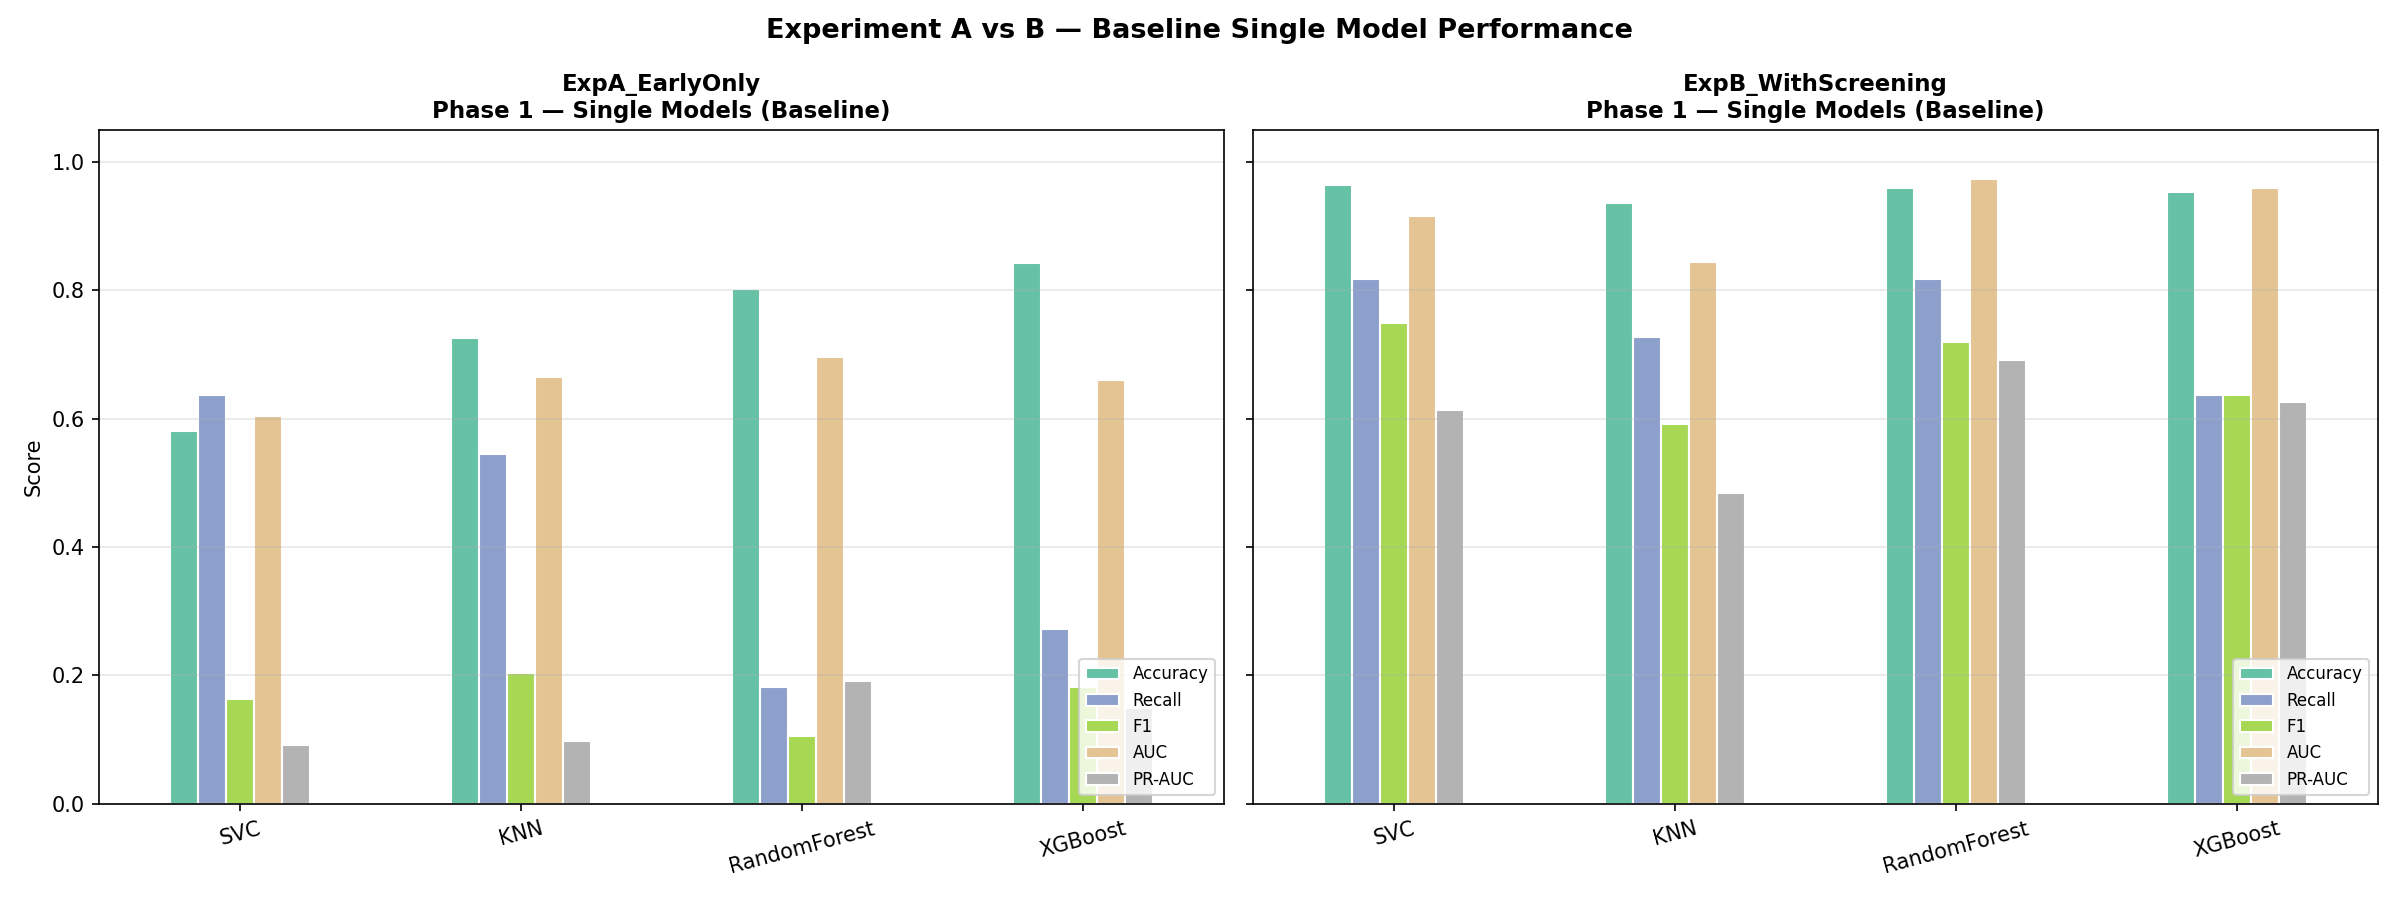

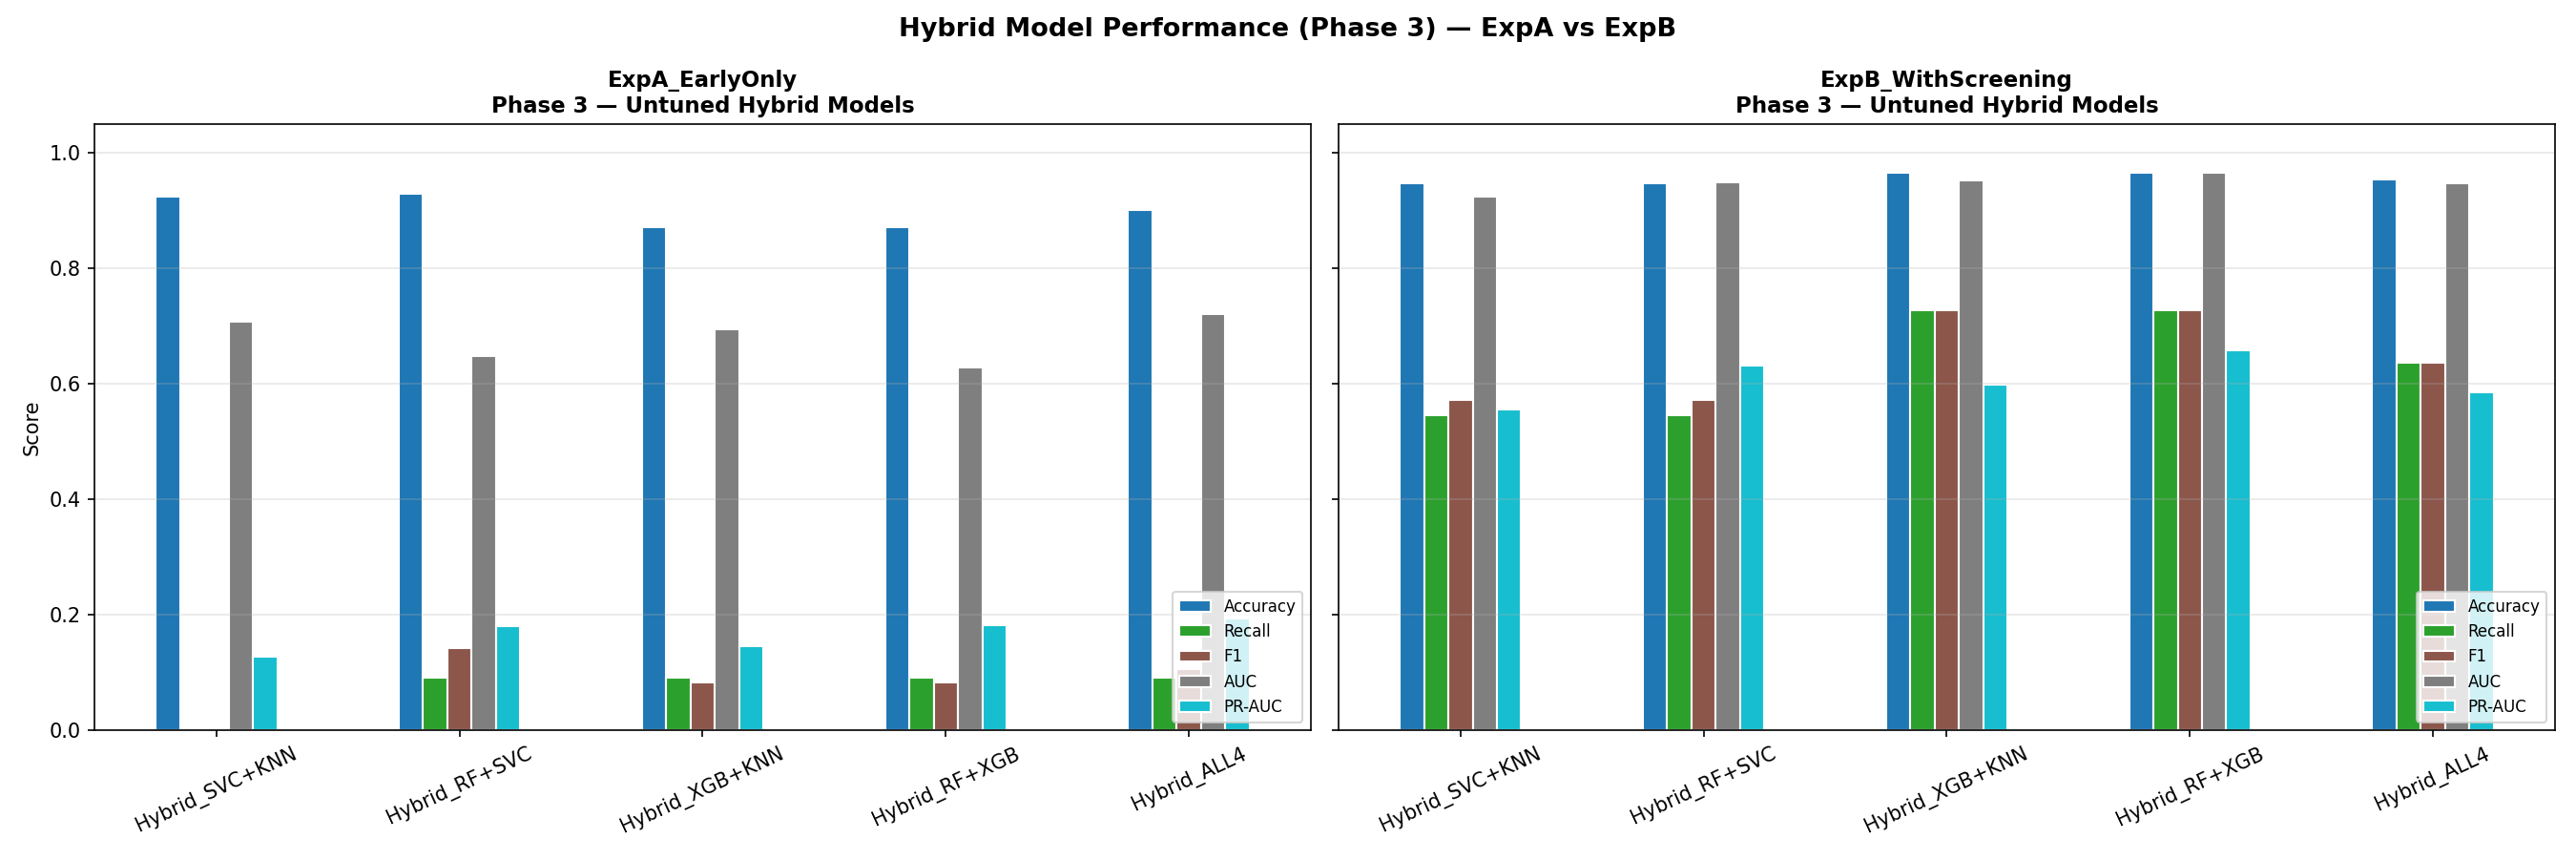

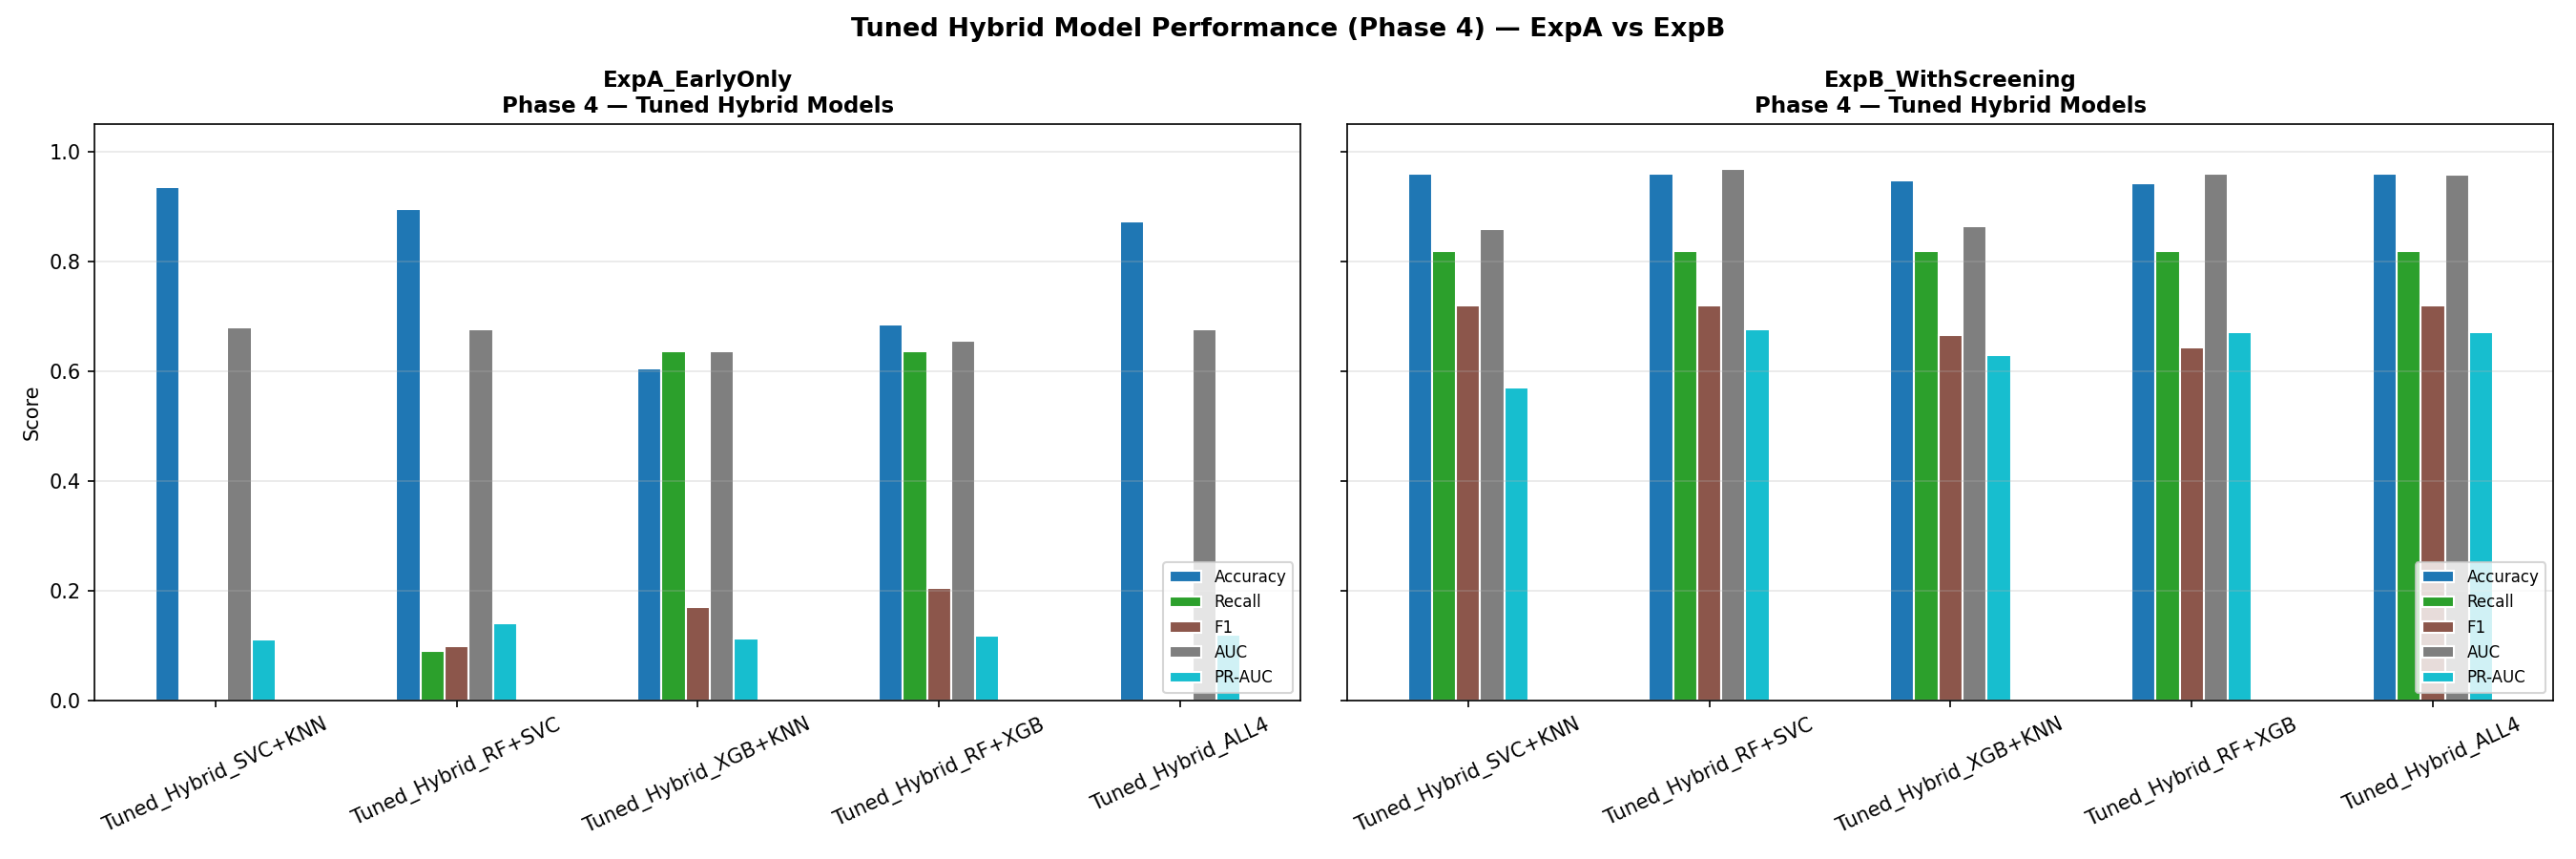

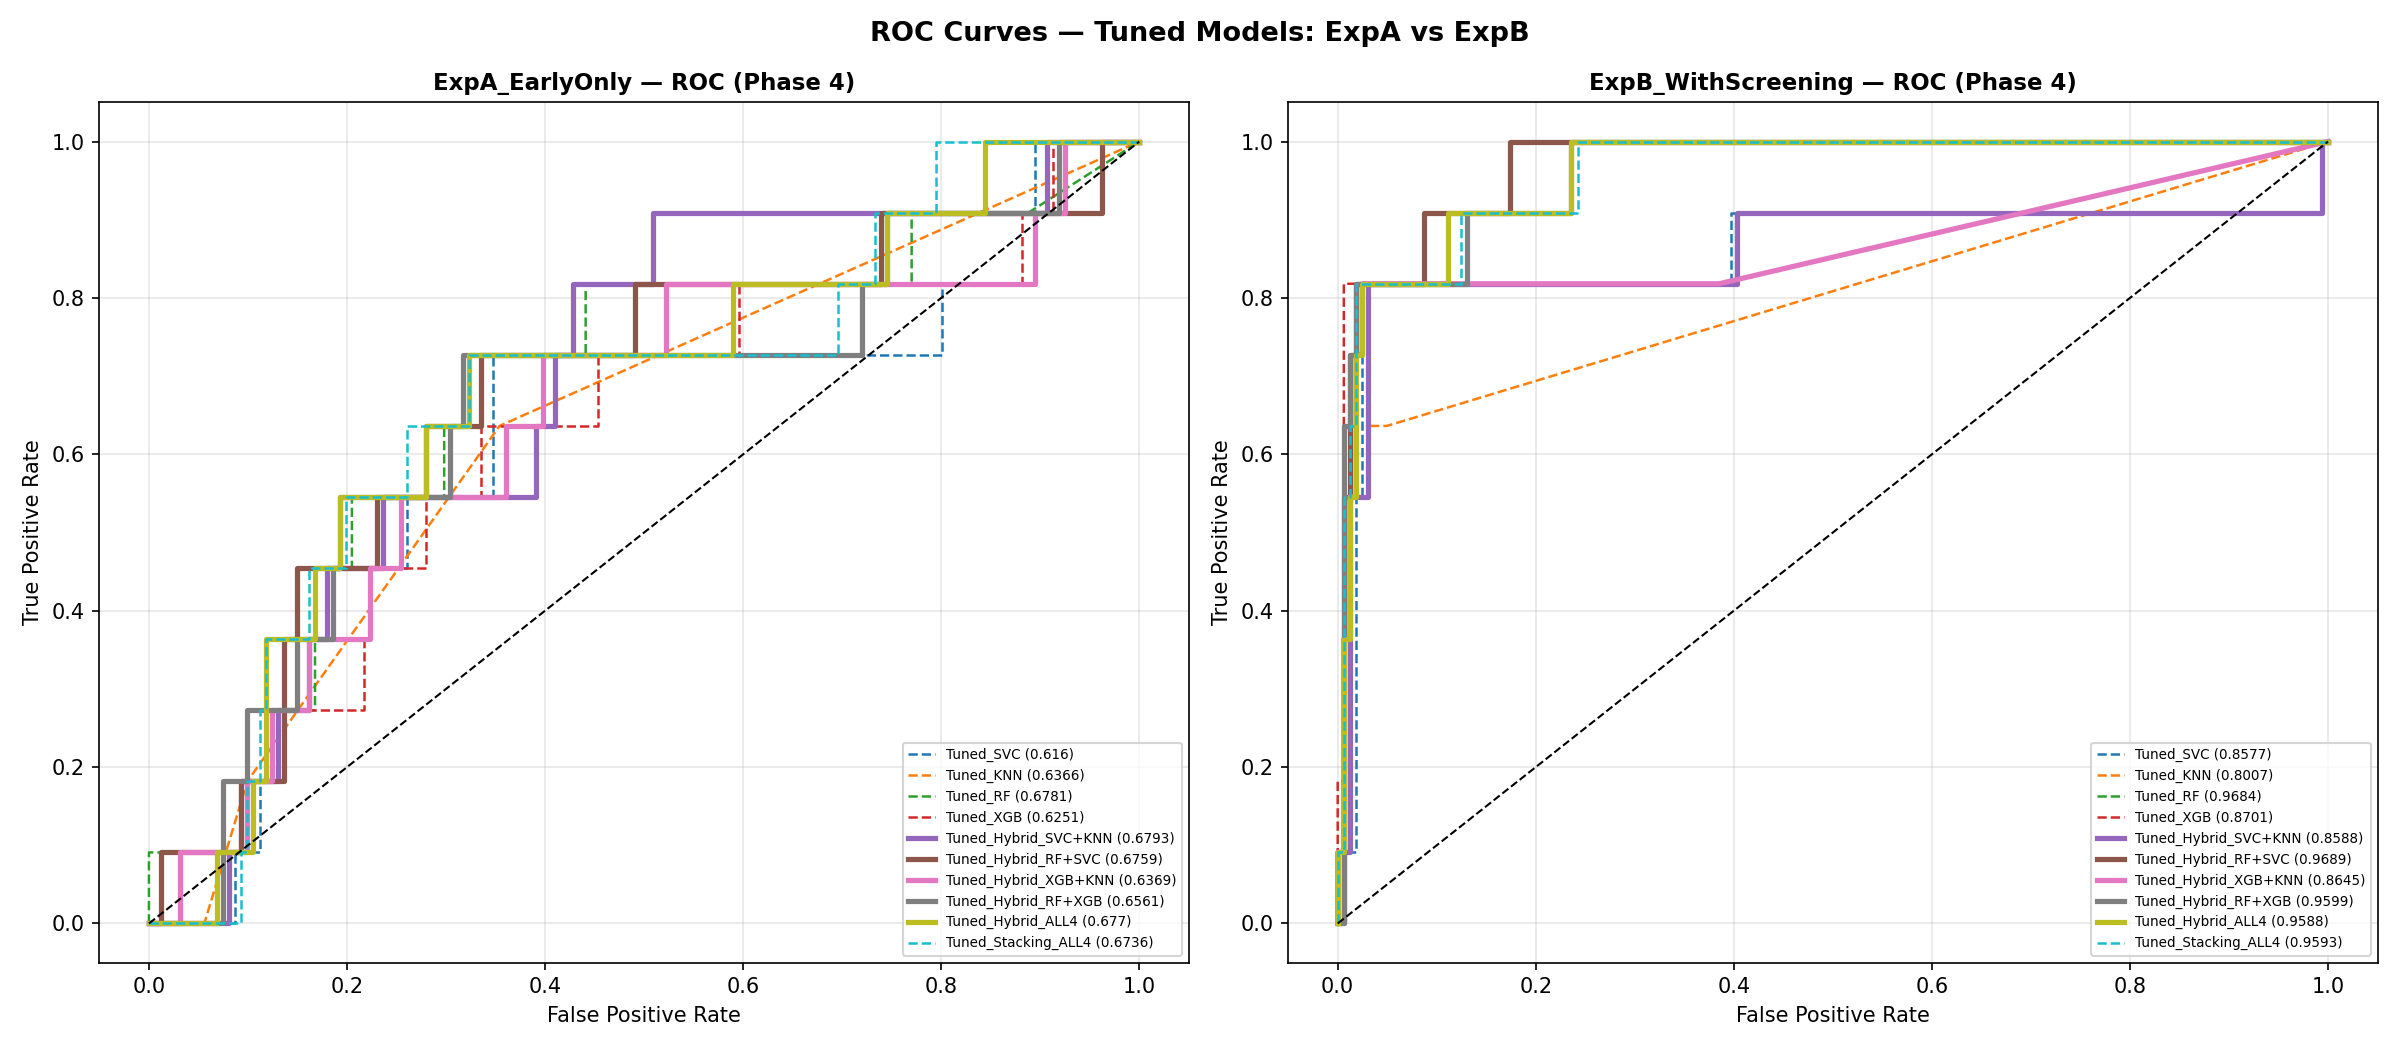

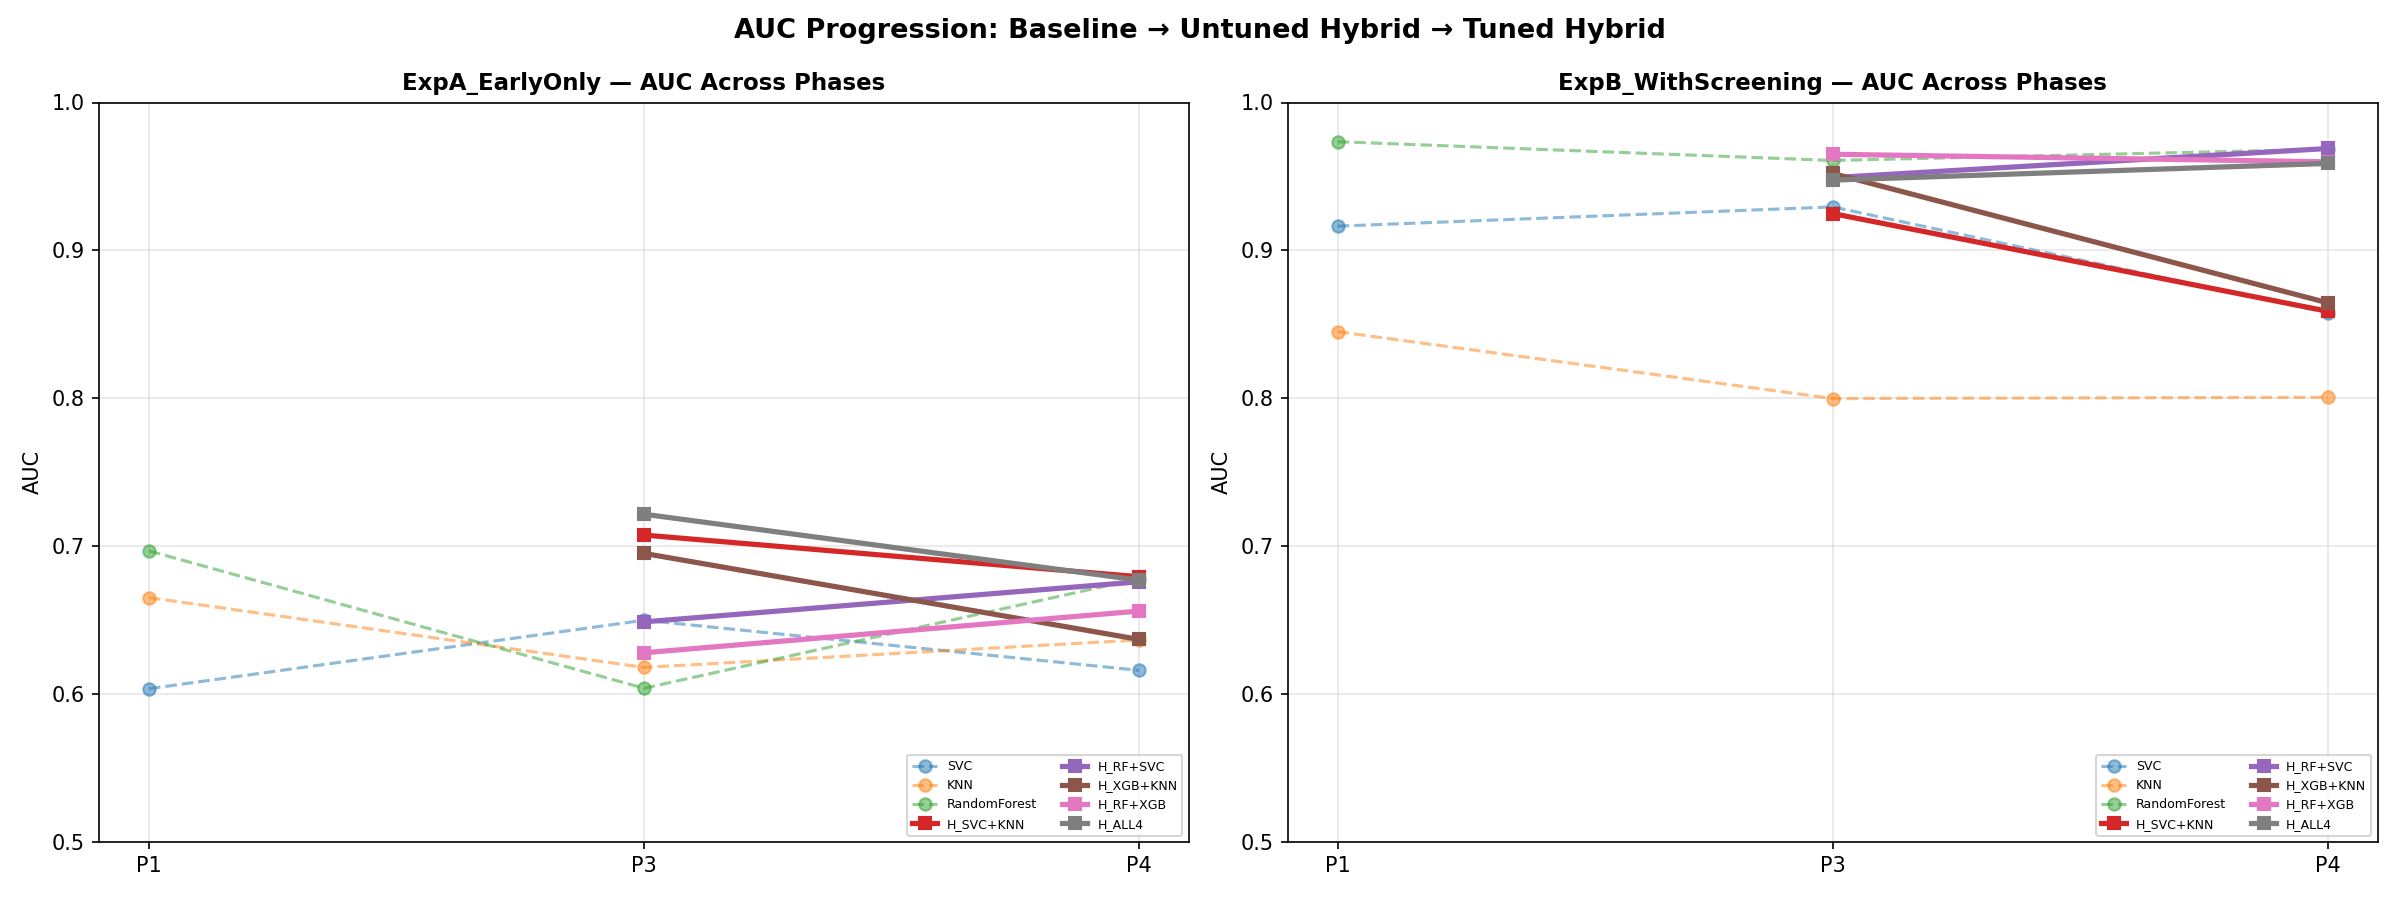

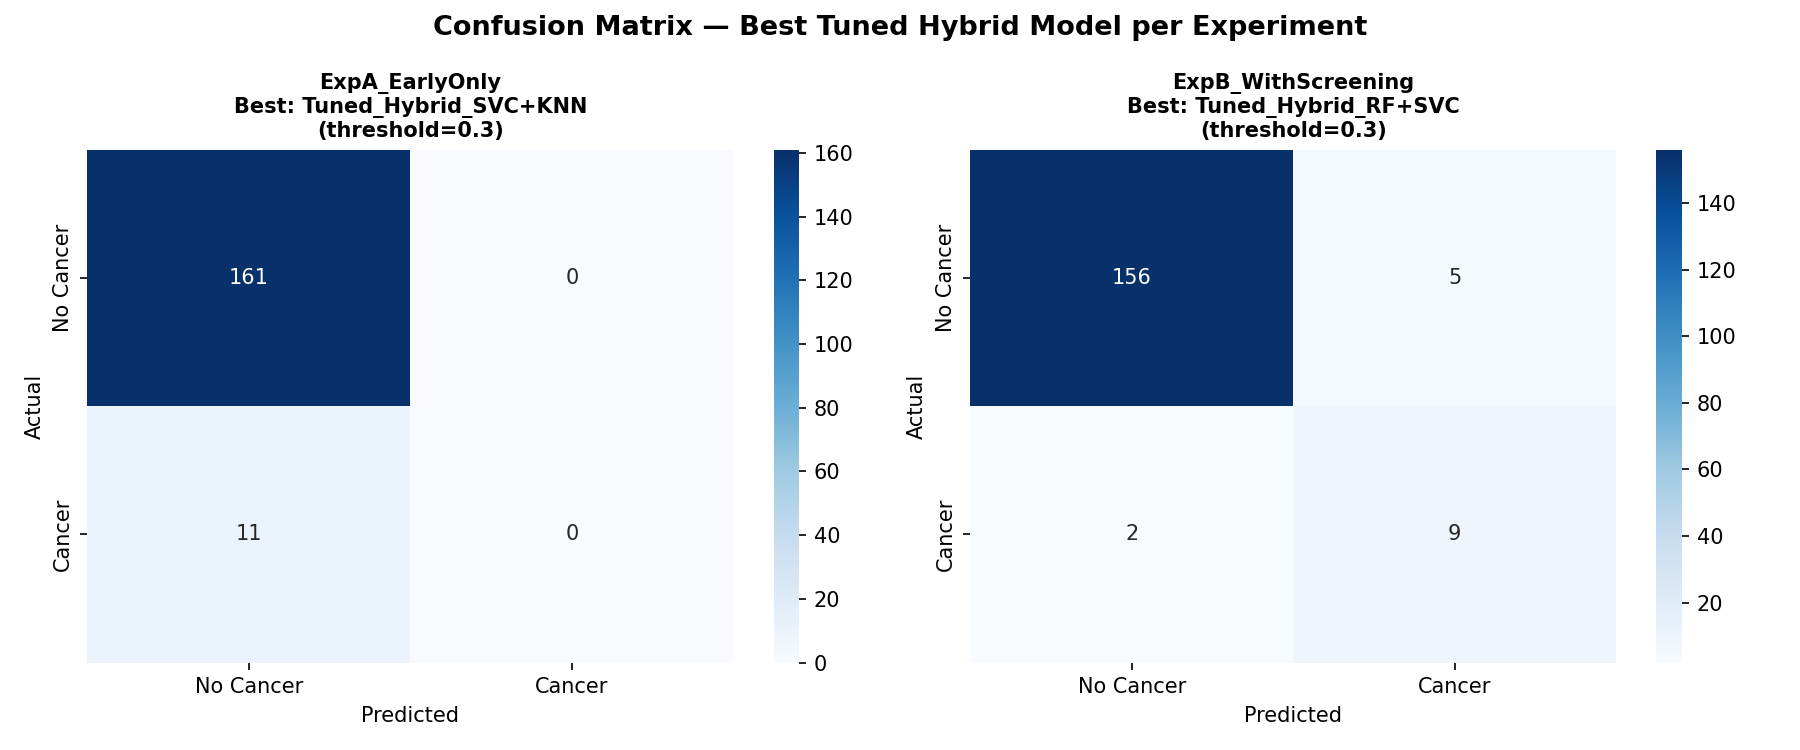

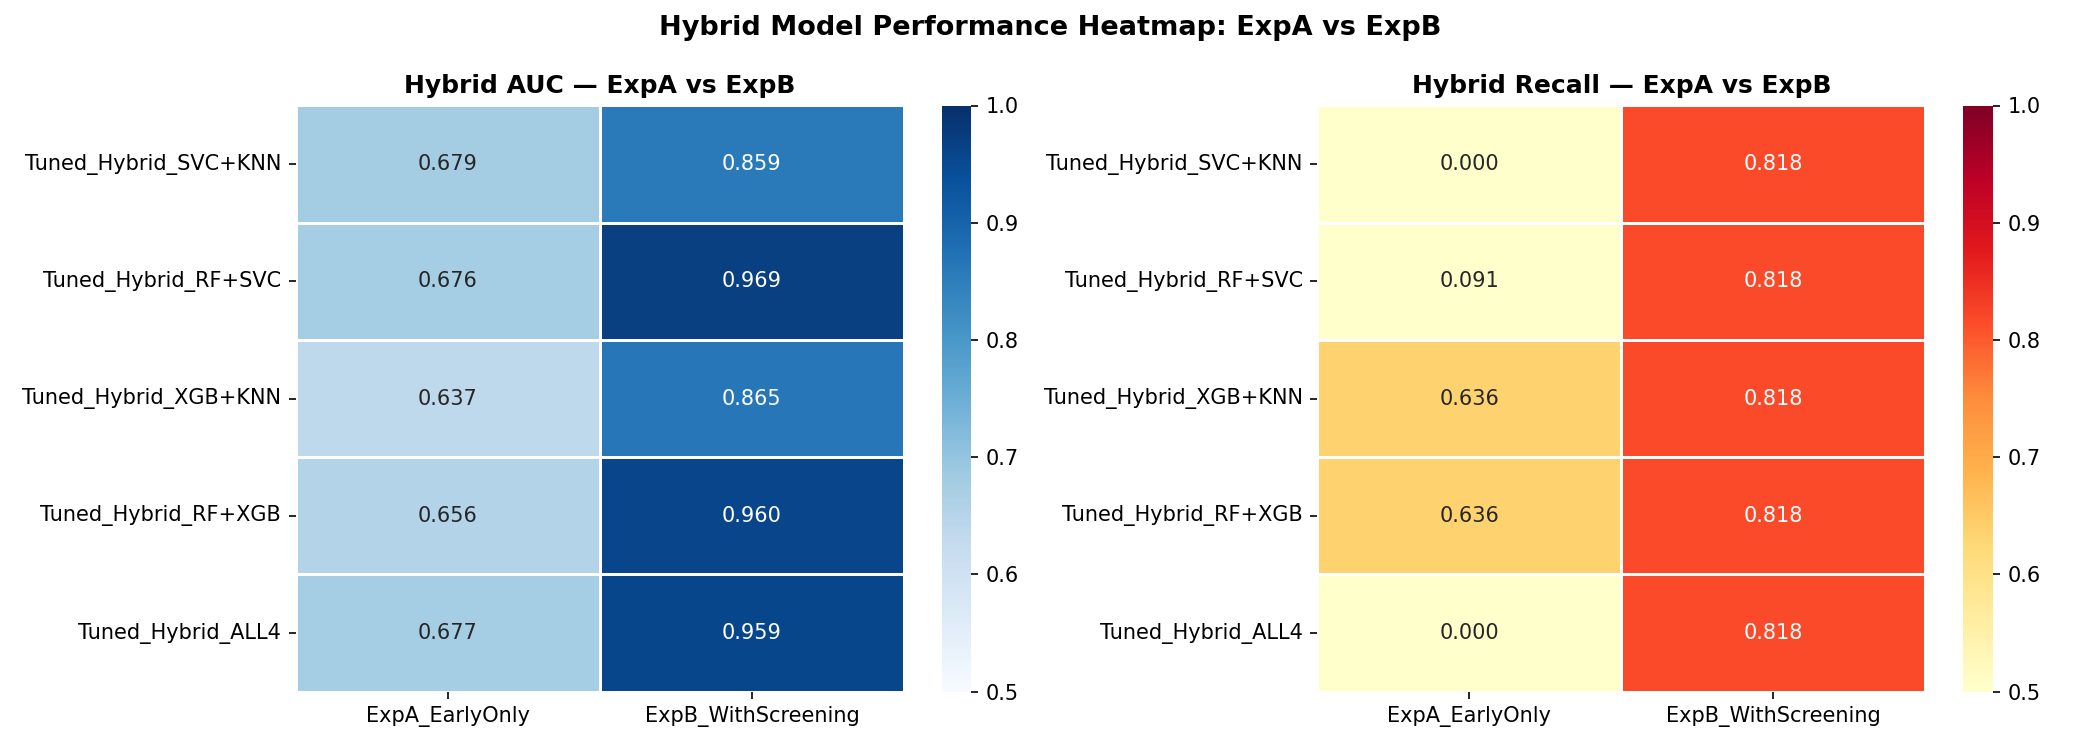

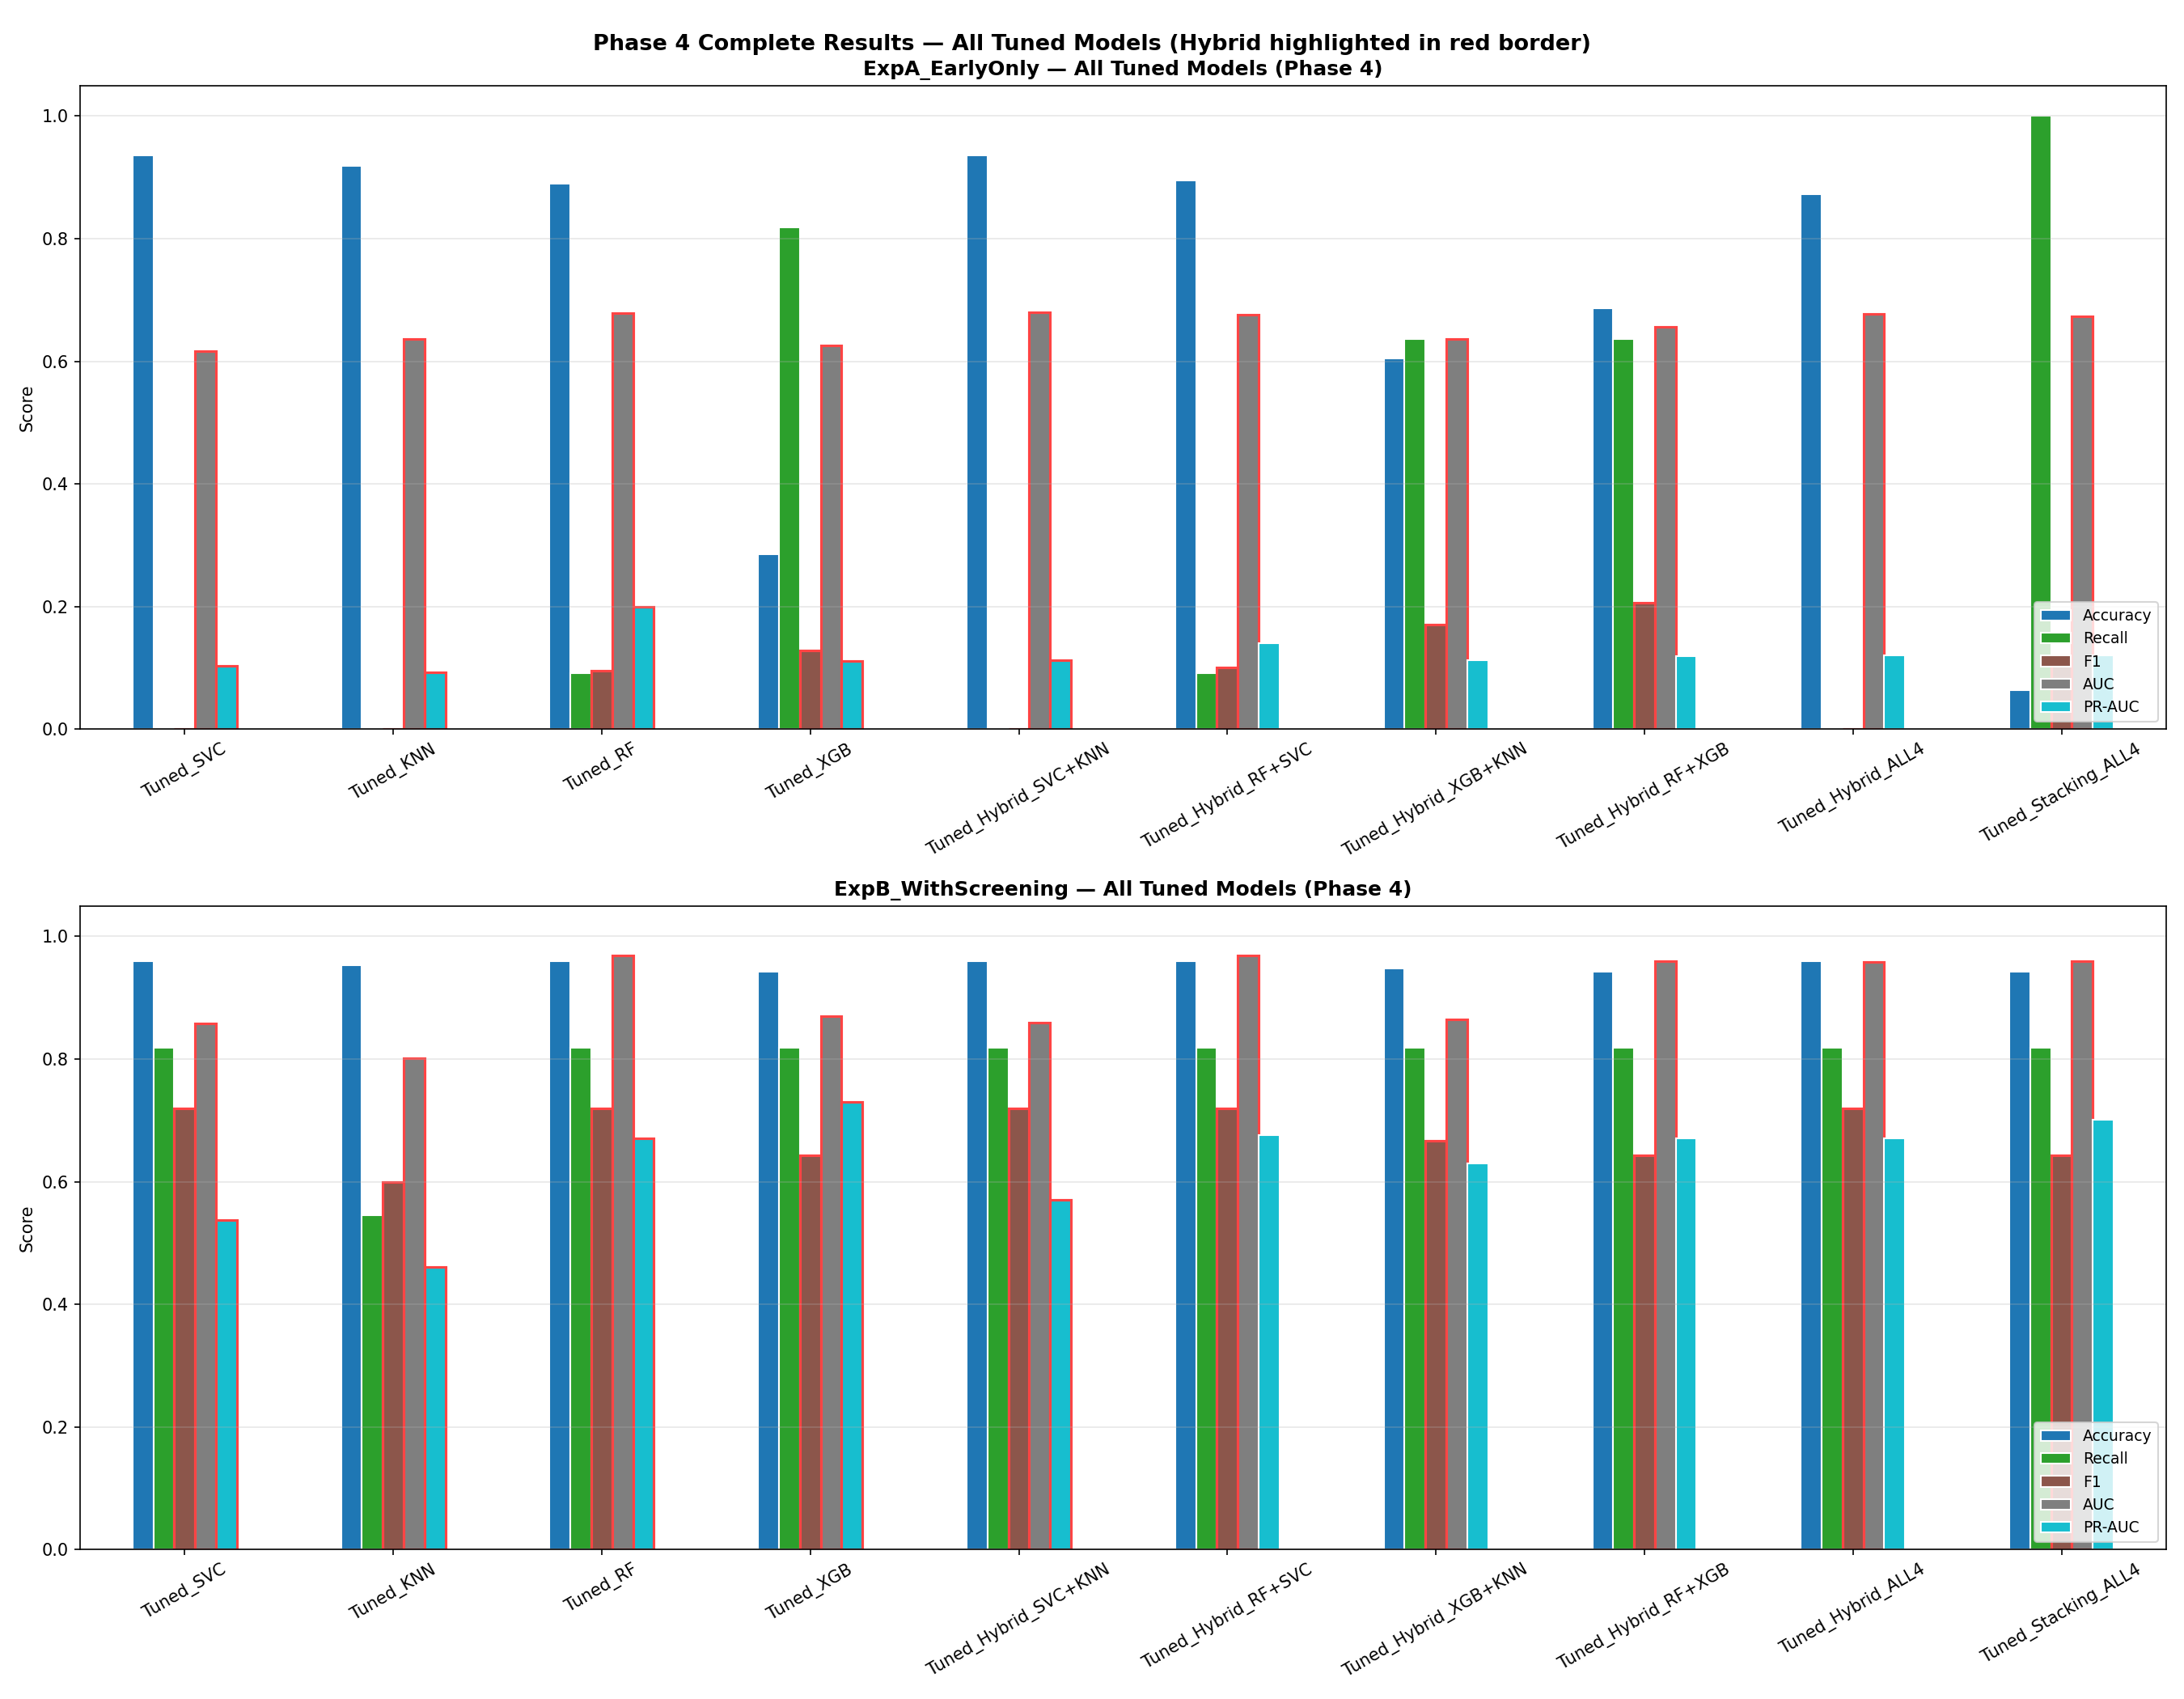

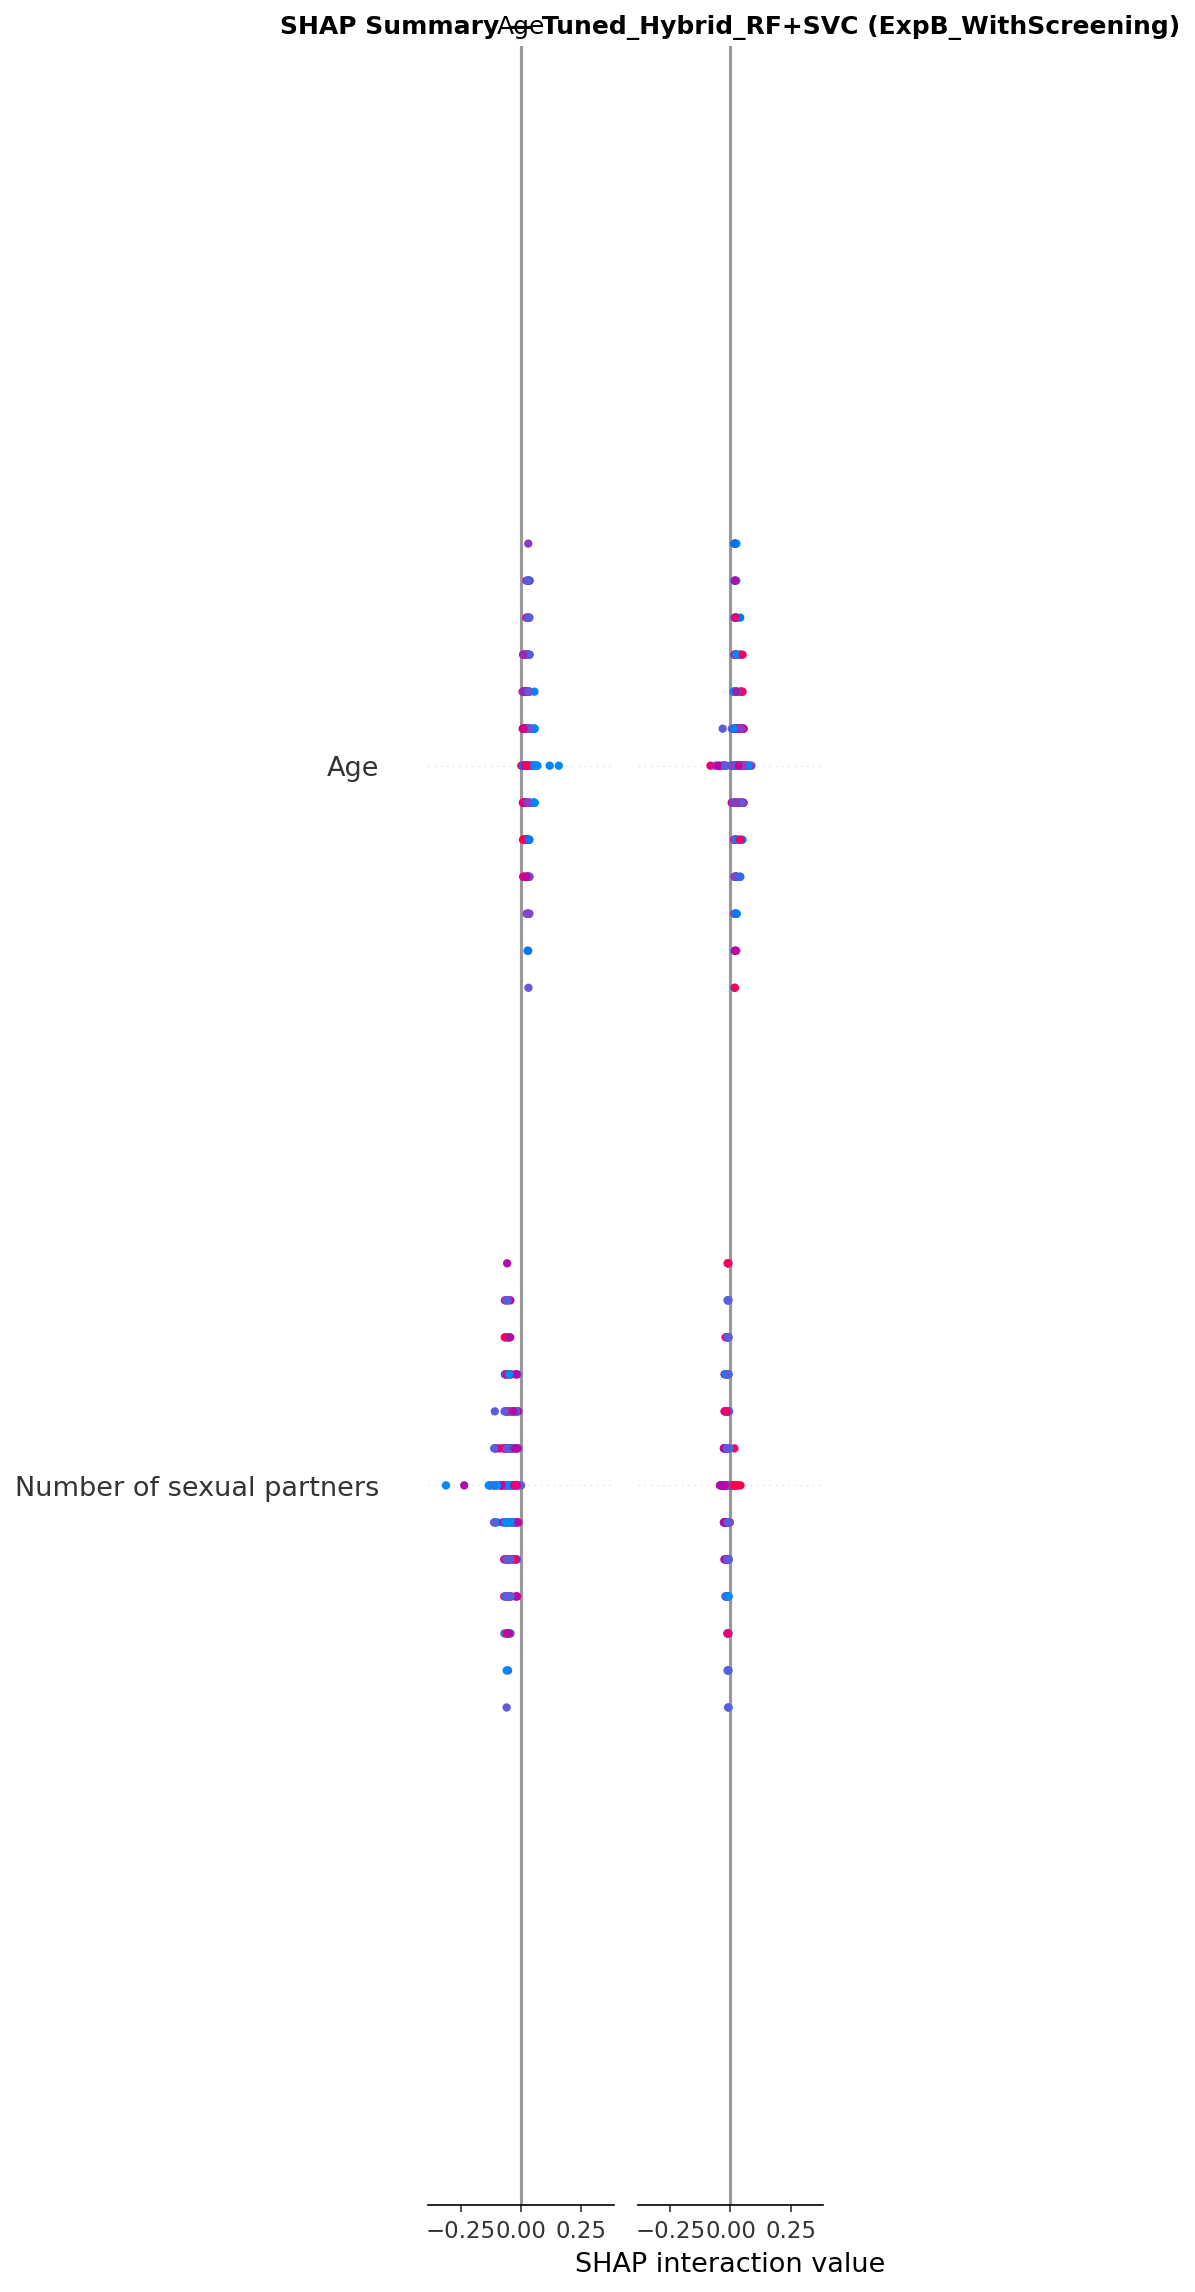

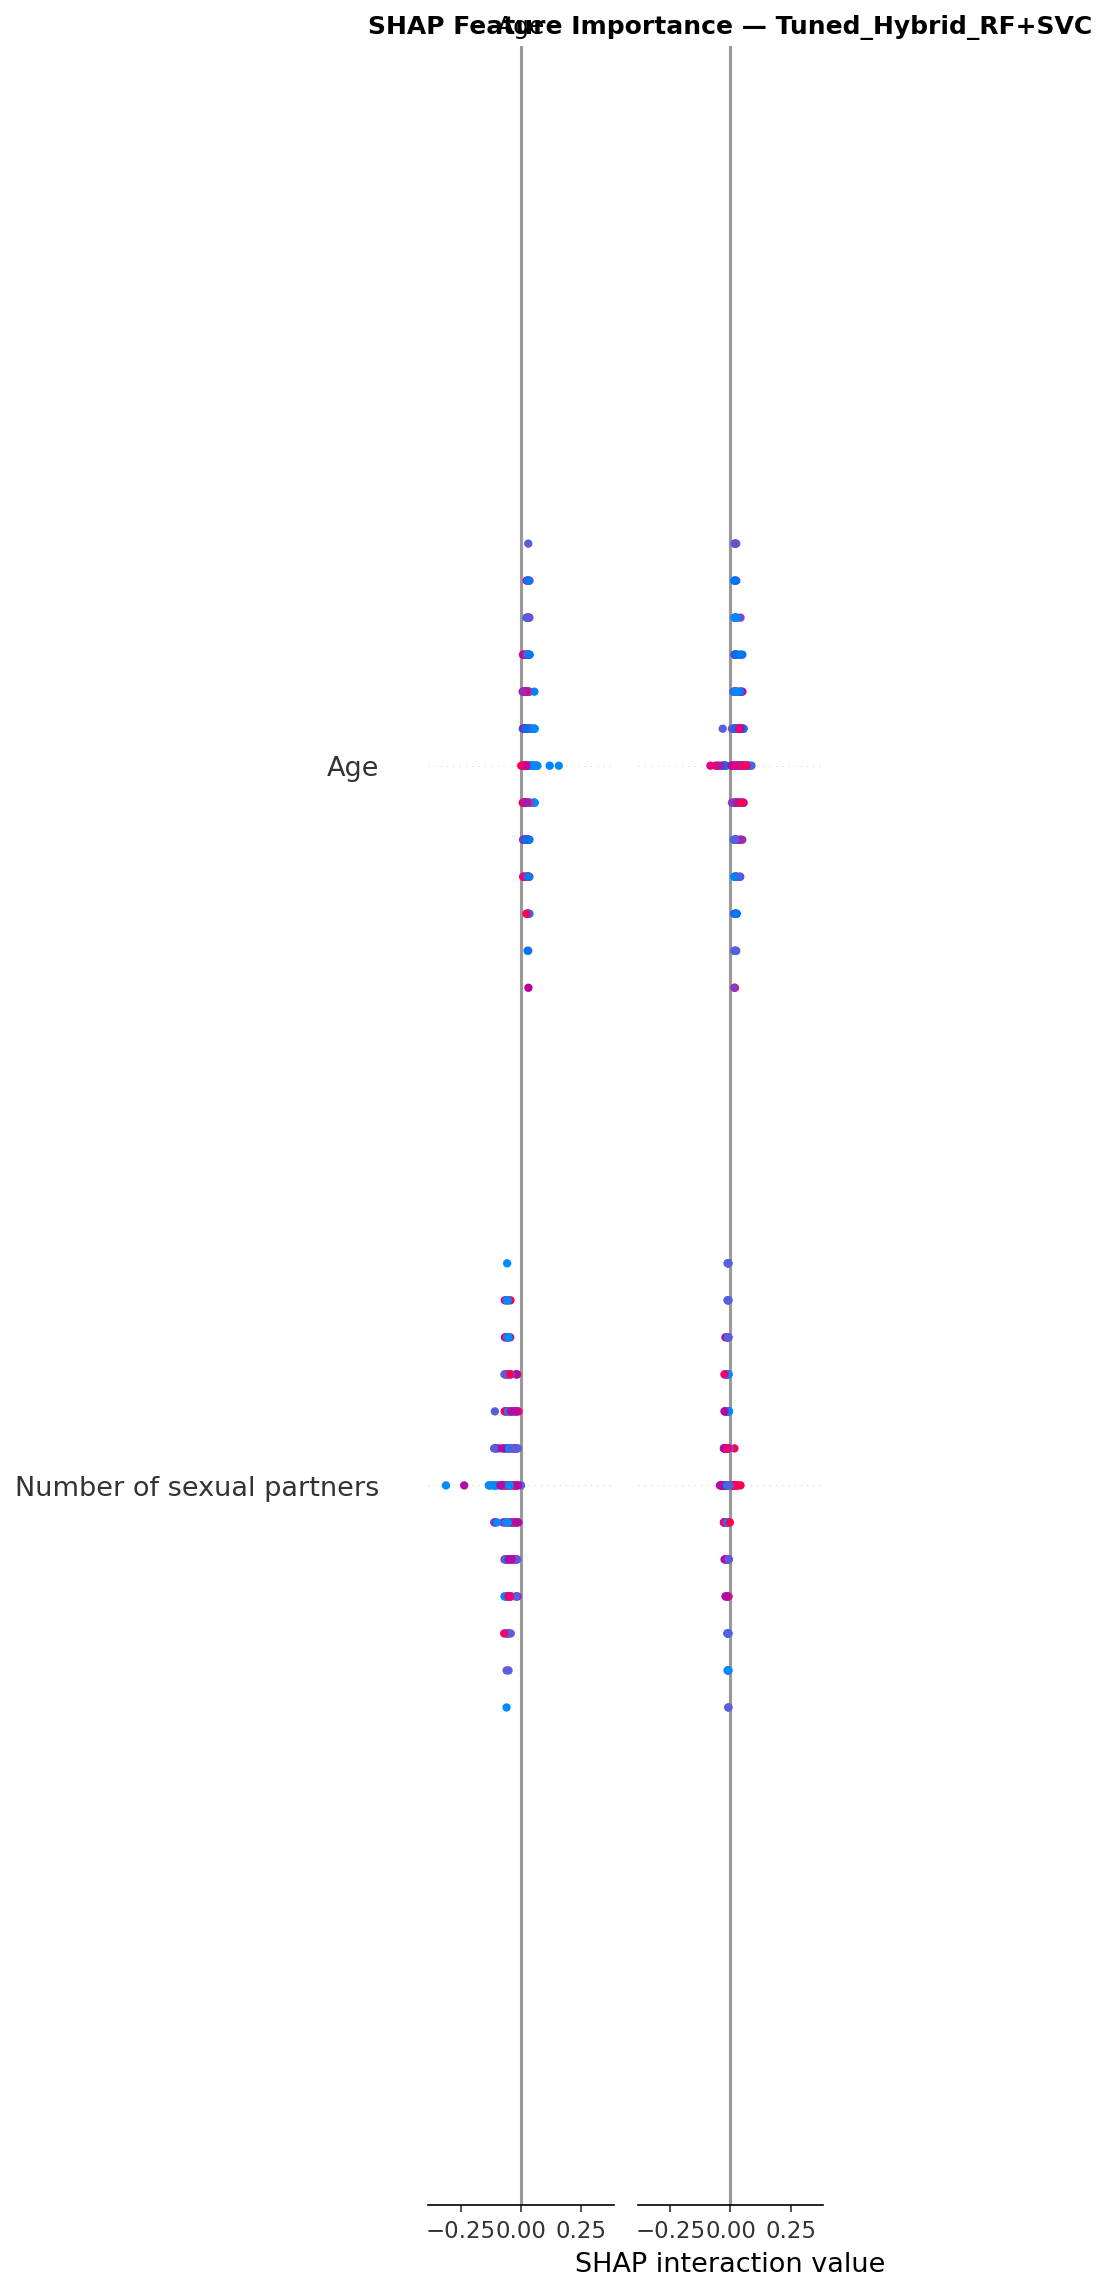

In [19]:
from IPython.display import Image, display

image_files = [
    "viz1_expA_vs_expB_baseline.png",
    "viz2_phase3_hybrid_comparison.png",
    "viz3_phase4_tuned_hybrid_comparison.png",
    "viz4_roc_tuned_expA_vs_expB.png",
    "viz5_auc_progression.png",
    "viz6_confusion_matrices.png",
    "viz7_hybrid_heatmap_expA_vs_expB.png",
    "viz8_phase4_full_both_experiments.png",
    "shap_summary_expB.png",
    "shap_importance_expB.png",
]

print("Displaying generated visualization files inline:")
for img in image_files:
    if os.path.exists(img):
        display(Image(filename=img))
    else:
        print(f"  Missing: {img}")